# WASHU and IU BANKSY Niches - atlasv2

In [1]:
from collections import OrderedDict
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.lines import Line2D

/home/reinert/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/reinert/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/home/reinert/.local/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/reinert/.local/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/reinert/.local/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing re

In [2]:
# paths and config

# input
WASHU_INTEGRATED_H5AD = Path("/storage2/fs1/sanjayjain/Active/Xenium/ATLASV2_REBUTTAL/resolvi_objs/kidney_4biopsies_resolvi_integrated.h5ad")
WASHU_BANKSY_H5AD     = Path("/storage2/fs1/sanjayjain/Active/Xenium/ATLASV2_REBUTTAL/BANKSY/objects/integrated_BANKSY_objs/NEW_BANKSY_4_biopsies_mincounts20_FULL.h5ad")
IU_INTEGRATED_H5AD    = Path("/storage2/fs1/sanjayjain/Active/Xenium/ATLASV2_REBUTTAL/resolvi_objs/kidney_IUSamples_resolvi_integrated.h5ad")
IU_BANKSY_H5AD        = Path("/storage2/fs1/sanjayjain/Active/Xenium/ATLASV2_REBUTTAL/BANKSY/objects/integrated_BANKSY_objs/NEW_BANKSY_IU_Samples_mincounts20_FULL.h5ad")

_inputs = {
    "WASHU integrated": WASHU_INTEGRATED_H5AD,
    "WASHU BANKSY":     WASHU_BANKSY_H5AD,
    "IU integrated":    IU_INTEGRATED_H5AD,
    "IU BANKSY":        IU_BANKSY_H5AD,
}

for name, path in _inputs.items():
    print(f"{'OK     ' if path.exists() else 'MISSING'}  {name:18s} {path}")

_missing = [n for n, p in _inputs.items() if not p.exists()]
if _missing:
    raise FileNotFoundError(f"Missing inputs: {_missing}")

# output
RESULTS_DIR     = Path("results")

TABLE_DIR       = RESULTS_DIR / "atlasv2_corrected_banksy_tables"   # similarity tables
FIGURE_DIR      = RESULTS_DIR / "corrected_banksy_tables"           # bubble figures
SPATIAL_DIR     = RESULTS_DIR / "corrected_banksy_spatial_maps"     # per-sample maps
EXPLORER_DIR    = RESULTS_DIR / "3811_Xen21_Xenium_Explorer"        # explorer CSVs
SOURCE_DATA_DIR = RESULTS_DIR / "source_data"                       # journal source data
H5AD_DIR        = RESULTS_DIR / "objects"                           # annotated objects

for directory in [TABLE_DIR, FIGURE_DIR, SPATIAL_DIR, EXPLORER_DIR,
                  SOURCE_DATA_DIR, H5AD_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# column names in the integrated objects
CLUSTER_COL    = "banksy_cluster_corrected"   # written by this notebook
ANNOTATION_COL = "v2.subclass.levelKIL"
SAMPLE_COL     = "sample"
CELL_ID_COL    = "cell_id"

# sample for xen explorer
EXPLORER_SAMPLE_ID = "3811_Xen21"

# whether to write the intermediate h5ad objects (large; off by default)
WRITE_H5AD = True

OK       WASHU integrated   /storage2/fs1/sanjayjain/Active/Xenium/ATLASV2_REBUTTAL/resolvi_objs/kidney_4biopsies_resolvi_integrated.h5ad
OK       WASHU BANKSY       /storage2/fs1/sanjayjain/Active/Xenium/ATLASV2_REBUTTAL/BANKSY/objects/integrated_BANKSY_objs/NEW_BANKSY_4_biopsies_mincounts20_FULL.h5ad
OK       IU integrated      /storage2/fs1/sanjayjain/Active/Xenium/ATLASV2_REBUTTAL/resolvi_objs/kidney_IUSamples_resolvi_integrated.h5ad
OK       IU BANKSY          /storage2/fs1/sanjayjain/Active/Xenium/ATLASV2_REBUTTAL/BANKSY/objects/integrated_BANKSY_objs/NEW_BANKSY_IU_Samples_mincounts20_FULL.h5ad


In [3]:
# shared helpers

def natural_sort(values):
    """Sort numeric labels numerically and non-numeric labels alphabetically."""
    def key(value):
        value = str(value)
        try:
            return (0, int(value))
        except ValueError:
            return (1, value)

    return sorted({str(value) for value in values}, key=key)


def make_cluster_palette(cluster_values, cmap_name="tab20"):
    """Assign one color per cluster, ordered by natural_sort."""
    cluster_order = natural_sort(cluster_values)
    cmap = plt.get_cmap(cmap_name, len(cluster_order))

    palette = {
        cluster: cmap(index)
        for index, cluster in enumerate(cluster_order)
    }

    return cluster_order, palette

In [4]:
# load objs

washu        = sc.read_h5ad(WASHU_INTEGRATED_H5AD)
washu_banksy = sc.read_h5ad(WASHU_BANKSY_H5AD)

iu           = sc.read_h5ad(IU_INTEGRATED_H5AD)
iu_banksy    = sc.read_h5ad(IU_BANKSY_H5AD)

for name, adata in [("WASHU integrated", washu), ("WASHU BANKSY", washu_banksy),
                    ("IU integrated", iu), ("IU BANKSY", iu_banksy)]:
    print(f"{name:20s} {adata.shape}  obs_names unique: {adata.obs_names.is_unique}")

WASHU integrated     (60956, 299)  obs_names unique: True
WASHU BANKSY         (60956, 299)  obs_names unique: True
IU integrated        (342597, 300)  obs_names unique: True
IU BANKSY            (342597, 300)  obs_names unique: True


In [5]:
# banksy labels to integrated objs

def verify_integrated_banksy_alignment(
    integrated,
    banksy,
    cohort_name,
    sample_col=SAMPLE_COL,
    cell_id_col=CELL_ID_COL,
    cluster_col="banksy_clusters",
):
    """Align BANKSY obs to the integrated object and verify the match. Returns the aligned obs."""
    print("=" * 80)
    print(cohort_name)
    print("=" * 80)
    print(f"Integrated cells: {integrated.n_obs:,}")
    print(f"BANKSY cells:     {banksy.n_obs:,}")

    if not integrated.obs_names.is_unique:
        raise ValueError(f"{cohort_name}: integrated obs_names are not unique.")

    if not banksy.obs_names.is_unique:
        raise ValueError(f"{cohort_name}: BANKSY obs_names are not unique.")

    if cluster_col not in banksy.obs.columns:
        raise KeyError(f"{cohort_name}: {cluster_col!r} is absent from BANKSY obs.")

    missing_from_banksy = integrated.obs_names.difference(banksy.obs_names)
    extra_in_banksy = banksy.obs_names.difference(integrated.obs_names)

    print(f"\nExact same obs_name order: {integrated.obs_names.equals(banksy.obs_names)}")
    print(f"Integrated cells missing from BANKSY: {len(missing_from_banksy):,}")
    print(f"Extra cells in BANKSY:                {len(extra_in_banksy):,}")

    if len(missing_from_banksy) or len(extra_in_banksy):
        raise ValueError(
            f"{cohort_name}: integrated and BANKSY objects do not contain the same cells."
        )

    # Reindex rather than assume row order.
    banksy_obs = banksy.obs.reindex(integrated.obs_names)

    # Independently re-verify the join on two metadata columns.
    for col, label in [(cell_id_col, "cell_id"), (sample_col, "sample")]:
        if col not in integrated.obs or col not in banksy_obs:
            continue

        left = integrated.obs[col].astype(str).fillna("<NA>")
        right = banksy_obs[col].astype(str).fillna("<NA>")
        match = left.eq(right)

        print(f"Matching {label}: {match.sum():,}/{len(match):,} ({match.mean():.2%})")

        if not match.all():
            display(pd.DataFrame({"integrated": left, "banksy": right}).loc[~match].head(10))
            raise ValueError(f"{cohort_name}: {label} does not agree between objects.")

    n_missing_clusters = banksy_obs[cluster_col].isna().sum()
    print(f"\nMissing BANKSY assignments: {n_missing_clusters:,}")
    print("\nBANKSY cluster counts:")
    print(banksy_obs[cluster_col].value_counts(dropna=False).sort_index())

    if n_missing_clusters:
        raise ValueError(
            f"{cohort_name}: {n_missing_clusters:,} cells have no BANKSY assignment."
        )

    print(f"\n{cohort_name}: alignment checks passed.")
    return banksy_obs

In [6]:
# alignment check

washu_banksy_obs_aligned = verify_integrated_banksy_alignment(
    integrated=washu, banksy=washu_banksy, cohort_name="WASHU",
)

iu_banksy_obs_aligned = verify_integrated_banksy_alignment(
    integrated=iu, banksy=iu_banksy, cohort_name="IU",
)

WASHU
Integrated cells: 60,956
BANKSY cells:     60,956

Exact same obs_name order: False
Integrated cells missing from BANKSY: 0
Extra cells in BANKSY:                0
Matching cell_id: 60,956/60,956 (100.00%)
Matching sample: 60,956/60,956 (100.00%)

Missing BANKSY assignments: 0

BANKSY cluster counts:
banksy_clusters
0     10388
1      9604
2      7300
3      5433
4      4843
5      4767
6      4496
7      3340
8      2632
9      2536
10     2119
11     2004
12     1494
Name: count, dtype: int64

WASHU: alignment checks passed.
IU
Integrated cells: 342,597
BANKSY cells:     342,597

Exact same obs_name order: True
Integrated cells missing from BANKSY: 0
Extra cells in BANKSY:                0
Matching cell_id: 342,597/342,597 (100.00%)
Matching sample: 342,597/342,597 (100.00%)

Missing BANKSY assignments: 0

BANKSY cluster counts:
banksy_clusters
0     42885
1     36429
2     30975
3     30675
4     29427
5     27283
6     26519
7     25497
8     23643
9     21073
10    13467
11 

In [7]:
# see banksy clusters

for adata, aligned in [(washu, washu_banksy_obs_aligned), (iu, iu_banksy_obs_aligned)]:
    adata.obs[CLUSTER_COL] = aligned["banksy_clusters"].astype(str).astype("category")

print("WASHU corrected BANKSY clusters:")
print(washu.obs[CLUSTER_COL].value_counts().sort_index())

print("\nIU corrected BANKSY clusters:")
print(iu.obs[CLUSTER_COL].value_counts().sort_index())

WASHU corrected BANKSY clusters:
banksy_cluster_corrected
0     10388
1      9604
10     2119
11     2004
12     1494
2      7300
3      5433
4      4843
5      4767
6      4496
7      3340
8      2632
9      2536
Name: count, dtype: int64

IU corrected BANKSY clusters:
banksy_cluster_corrected
0     42885
1     36429
10    13467
11    11670
12    10346
13     8263
14     4445
2     30975
3     30675
4     29427
5     27283
6     26519
7     25497
8     23643
9     21073
Name: count, dtype: int64


In [8]:
# validate

for cohort, source, target in [("WASHU", washu_banksy, washu), ("IU", iu_banksy, iu)]:
    source_counts = source.obs["banksy_clusters"].astype(str).value_counts().sort_index()
    target_counts = target.obs[CLUSTER_COL].astype(str).value_counts().sort_index()
    pd.testing.assert_series_equal(source_counts, target_counts, check_names=False)

    assert target.obs[CLUSTER_COL].notna().all(), f"{cohort}: NaN clusters after transfer"

print("Cluster-count validation passed for both cohorts.")

Cluster-count validation passed for both cohorts.


In [9]:
# four columns

def prepare_banksy_obs(
    adata,
    cohort,
    cluster_col=CLUSTER_COL,
    annotation_col=ANNOTATION_COL,
    sample_col=SAMPLE_COL,
):
    required = [cluster_col, annotation_col, sample_col]

    missing_columns = [col for col in required if col not in adata.obs.columns]
    if missing_columns:
        raise KeyError(f"{cohort}: missing required columns: {missing_columns}")

    if not adata.obs_names.is_unique:
        raise ValueError(f"{cohort}: obs_names are not unique.")

    obs = adata.obs[required].copy()
    obs = obs.rename(columns={
        cluster_col: "Cluster",
        annotation_col: "Annotation",
        sample_col: "Sample",
    })

    obs.insert(0, "cell_key", adata.obs_names.astype(str))
    obs.insert(0, "Cohort", cohort)

    for col in ["Cluster", "Annotation", "Sample"]:
        obs[col] = obs[col].astype("string").str.strip()

    missing = obs[["Cluster", "Annotation", "Sample"]].isna().sum()
    if missing.any():
        print(f"\n{cohort} missing metadata:")
        print(missing)
        raise ValueError(
            f"{cohort}: cells are missing cluster, annotation, or sample metadata."
        )

    print(f"\n{cohort}")
    print(f"Cells:       {len(obs):,}")
    print(f"Samples:     {obs['Sample'].nunique():,}")
    print(f"Clusters:    {obs['Cluster'].nunique():,}")
    print(f"Annotations: {obs['Annotation'].nunique():,}")

    return obs


washu_obs = prepare_banksy_obs(washu, cohort="WASHU")
iu_obs = prepare_banksy_obs(iu, cohort="IU")


WASHU
Cells:       60,956
Samples:     4
Clusters:    13
Annotations: 45

IU
Cells:       342,597
Samples:     10
Clusters:    15
Annotations: 45


In [10]:
# check annotations

washu_annotations = set(washu_obs["Annotation"].dropna().astype(str))
iu_annotations = set(iu_obs["Annotation"].dropna().astype(str))

print(f"WASHU annotations: {len(washu_annotations)}")
print(f"IU annotations:    {len(iu_annotations)}")
print("\nWASHU-only:", sorted(washu_annotations - iu_annotations))
print("IU-only:   ", sorted(iu_annotations - washu_annotations))

assert washu_annotations == iu_annotations, (
    "The two cohorts do not have identical annotation vocabularies."
)

# Every annotation present in either cohort. Used to validate the panel maps.
all_present_annotations = sorted(washu_annotations | iu_annotations)

print(f"\nAnnotation vocabularies match exactly ({len(all_present_annotations)} labels).")
print(all_present_annotations)

WASHU annotations: 45
IU annotations:    45

WASHU-only: []
IU-only:    []

Annotation vocabularies match exactly (45 labels).
['ATL', 'B', 'CNT', 'DC', 'DCT', 'DTL', 'EC', 'EC-GC', 'ERY', 'FIB', 'IC', 'MAC', 'MAST', 'MC', 'MD', 'MON', 'MYOF', 'N', 'NK', 'PC', 'PEC', 'PL', 'POD', 'PT', 'REN', 'SC_NEU', 'T', 'TAL', 'VSMC', 'VSMC_P', 'altATL', 'altCNT', 'altDCT', 'altDTL', 'altFIB', 'altIC', 'altPC', 'altPOD', 'altPT', 'altTAL', 'infFIB', 'moMAC', 'moMAC-INF', 'pvFIB', 'resMAC']


In [11]:
# clusster overview

def make_cluster_overview(obs):
    """Per-cluster size and sample spread."""
    cluster_counts = obs.groupby("Cluster", observed=True).size().rename("ClusterCells")

    sample_counts = pd.crosstab(obs["Cluster"], obs["Sample"])
    sample_fractions = sample_counts.div(sample_counts.sum(axis=1), axis=0)

    overview = pd.DataFrame({
        "ClusterCells": cluster_counts,
        "ClusterPercent": cluster_counts / len(obs),
        "SamplesRepresented": (sample_counts > 0).sum(axis=1),
        "DominantSample": sample_fractions.idxmax(axis=1),
        "DominantSampleFraction": sample_fractions.max(axis=1),
    }).reset_index()

    order = {cluster: i for i, cluster in enumerate(natural_sort(overview["Cluster"]))}
    overview = (
        overview
        .assign(_order=overview["Cluster"].astype(str).map(order))
        .sort_values("_order")
        .drop(columns="_order")
        .reset_index(drop=True)
    )

    return overview, sample_counts, sample_fractions


washu_cluster_overview, washu_sample_counts, washu_sample_fractions = make_cluster_overview(washu_obs)
iu_cluster_overview, iu_sample_counts, iu_sample_fractions = make_cluster_overview(iu_obs)

display(washu_cluster_overview)
display(iu_cluster_overview)

,Cluster,ClusterCells,ClusterPercent,SamplesRepresented,DominantSample,DominantSampleFraction
0,0,10388,0.170418,4,3729_Xen21,0.372930
1,1,9604,0.157556,4,3811_Xen21,0.456789
2,2,7300,0.119759,4,3811_Xen21,0.299178
3,3,5433,0.089130,4,3811_Xen21,0.267808
4,4,4843,0.079451,4,3809_Xen22B,0.374974
5,5,4767,0.078204,4,3811_Xen21,0.468848
6,6,4496,0.073758,4,3811_Xen21,0.415703
7,7,3340,0.054794,4,3809_Xen22A,0.350000
8,8,2632,0.043179,4,3729_Xen21,0.364362
9,9,2536,0.041604,4,3811_Xen21,0.369085


,Cluster,ClusterCells,ClusterPercent,SamplesRepresented,DominantSample,DominantSampleFraction
0,0,42885,0.125176,10,IU06,0.259065
1,1,36429,0.106332,10,IU17,0.211617
2,2,30975,0.090412,10,IU08,0.208846
3,3,30675,0.089537,10,IU08,0.202804
4,4,29427,0.085894,10,IU17,0.195501
5,5,27283,0.079636,10,IU17,0.217645
6,6,26519,0.077406,10,IU17,0.208567
7,7,25497,0.074423,10,IU09,0.183865
8,8,23643,0.069011,10,IU17,0.204839
9,9,21073,0.061510,10,IU17,0.252503


In [12]:
# build table and check

def build_cluster_annotation_table(obs):
    table = (
        obs.groupby(["Cluster", "Annotation"], observed=True)
        .size()
        .rename("Count")
        .reset_index()
    )

    table["ClusterCells"] = table.groupby("Cluster", observed=True)["Count"].transform("sum")
    table["AnnotationCells"] = table.groupby("Annotation", observed=True)["Count"].transform("sum")

    # What proportion of this BANKSY cluster is this cell type?
    table["FractionOfCluster"] = table["Count"] / table["ClusterCells"]

    # What proportion of this cell type was assigned to this cluster?
    # This is the quantity plotted as bubble size.
    table["FractionOfAnnotation"] = table["Count"] / table["AnnotationCells"]

    return table


washu_cluster_annotation = build_cluster_annotation_table(washu_obs)
iu_cluster_annotation = build_cluster_annotation_table(iu_obs)

# Both normalizations must close.
for cohort, table in [("WASHU", washu_cluster_annotation), ("IU", iu_cluster_annotation)]:
    by_cluster = table.groupby("Cluster", observed=True)["FractionOfCluster"].sum()
    by_annotation = table.groupby("Annotation", observed=True)["FractionOfAnnotation"].sum()

    assert np.allclose(by_cluster, 1), f"{cohort}: FractionOfCluster does not sum to 1"
    assert np.allclose(by_annotation, 1), f"{cohort}: FractionOfAnnotation does not sum to 1"

print("Both fraction normalizations sum to 1 in both cohorts.")

Both fraction normalizations sum to 1 in both cohorts.


In [13]:
# top annotations

def get_top_annotations(cluster_annotation, n=8):
    """Top n cell types per cluster by share of that cluster."""
    result = (
        cluster_annotation
        .sort_values(["Cluster", "FractionOfCluster"], ascending=[True, False])
        .groupby("Cluster", observed=True, group_keys=False)
        .head(n)
        .copy()
    )

    result["Rank"] = result.groupby("Cluster", observed=True).cumcount() + 1

    return result[["Cluster", "Rank", "Annotation", "Count",
                   "FractionOfCluster", "FractionOfAnnotation"]]


def print_top_annotations(top_table, overview, cohort):
    print("=" * 80)
    print(cohort)
    print("=" * 80)

    for cluster in natural_sort(top_table["Cluster"]):
        rows = top_table.loc[top_table["Cluster"].astype(str) == str(cluster)]
        info = overview.loc[overview["Cluster"].astype(str) == str(cluster)].iloc[0]

        print(
            f"\nCluster {cluster}: {int(info['ClusterCells']):,} cells "
            f"({info['ClusterPercent']:.1%} of cohort); "
            f"{int(info['SamplesRepresented'])} samples; "
            f"largest sample = {info['DominantSample']} "
            f"({info['DominantSampleFraction']:.1%})"
        )

        for row in rows.itertuples():
            print(
                f"  {row.Annotation:<18} {row.Count:>7,} cells | "
                f"{row.FractionOfCluster:>6.1%} of cluster | "
                f"{row.FractionOfAnnotation:>6.1%} of cell type"
            )


washu_top_annotations = get_top_annotations(washu_cluster_annotation, n=8)
iu_top_annotations = get_top_annotations(iu_cluster_annotation, n=8)

print_top_annotations(washu_top_annotations, washu_cluster_overview, "WASHU")
print_top_annotations(iu_top_annotations, iu_cluster_overview, "IU")

WASHU

Cluster 0: 10,388 cells (17.0% of cohort); 4 samples; largest sample = 3729_Xen21 (37.3%)
  FIB                  2,437 cells |  23.5% of cluster |  35.7% of cell type
  resMAC               1,335 cells |  12.9% of cluster |  57.4% of cell type
  T                    1,323 cells |  12.7% of cluster |  85.7% of cell type
  infFIB                 780 cells |   7.5% of cluster |  67.4% of cell type
  altFIB                 553 cells |   5.3% of cluster |  49.3% of cell type
  EC                     514 cells |   4.9% of cluster |   8.8% of cell type
  MYOF                   508 cells |   4.9% of cluster |  41.1% of cell type
  DC                     501 cells |   4.8% of cluster |  72.2% of cell type

Cluster 1: 9,604 cells (15.8% of cohort); 4 samples; largest sample = 3811_Xen21 (45.7%)
  PT                   5,546 cells |  57.7% of cluster |  67.0% of cell type
  altPT                3,982 cells |  41.5% of cluster |  53.4% of cell type
  altDTL                  26 cells |   0.3%

In [14]:
# cluster cohort similarity

def build_cluster_profile(cluster_annotation_table, prefix, all_annotations):
    """Cluster x annotation composition matrix, reindexed to a common vocabulary."""
    profile = cluster_annotation_table.pivot_table(
        index="Cluster",
        columns="Annotation",
        values="FractionOfCluster",
        fill_value=0,
        observed=True,
    )

    profile.index = profile.index.astype(str)
    profile.columns = profile.columns.astype(str)
    profile = profile.reindex(columns=all_annotations, fill_value=0)
    profile = profile.loc[natural_sort(profile.index)]
    profile.index = [f"{prefix}_{cluster}" for cluster in profile.index]

    if not np.allclose(profile.sum(axis=1), 1):
        raise ValueError(f"{prefix}: cluster profiles do not sum to 1.")

    return profile


def cosine_similarity_matrix(left, right):
    left_values = left.to_numpy(dtype=float)
    right_values = right.to_numpy(dtype=float)

    left_norms = np.linalg.norm(left_values, axis=1, keepdims=True)
    right_norms = np.linalg.norm(right_values, axis=1, keepdims=True)

    if np.any(left_norms == 0) or np.any(right_norms == 0):
        raise ValueError("At least one cluster has an all-zero composition profile.")

    values = (left_values / left_norms) @ (right_values / right_norms).T

    return pd.DataFrame(values, index=left.index, columns=right.index)


washu_profile = build_cluster_profile(
    washu_cluster_annotation, prefix="WASHU", all_annotations=all_present_annotations,
)

iu_profile = build_cluster_profile(
    iu_cluster_annotation, prefix="IU", all_annotations=all_present_annotations,
)

composition_similarity = cosine_similarity_matrix(washu_profile, iu_profile)

print("WASHU profile shape:", washu_profile.shape)
print("IU profile shape:   ", iu_profile.shape)
display(composition_similarity.round(3))

WASHU profile shape: (13, 45)
IU profile shape:    (15, 45)


,IU_0,IU_1,IU_2,IU_3,IU_4,IU_5,IU_6,IU_7,IU_8,IU_9,IU_10,IU_11,IU_12,IU_13,IU_14
WASHU_0,0.011,0.775,0.685,0.530,0.018,0.159,0.538,0.058,0.027,0.163,0.849,0.245,0.081,0.007,0.728
WASHU_1,0.995,0.010,0.094,0.009,0.708,0.005,0.014,0.056,0.003,0.027,0.024,0.008,0.017,0.983,0.333
WASHU_2,0.018,0.758,0.557,0.159,0.028,0.666,0.228,0.090,0.044,0.383,0.773,0.240,0.108,0.015,0.745
WASHU_3,0.486,0.022,0.216,0.058,0.899,0.008,0.039,0.321,0.259,0.060,0.109,0.014,0.106,0.445,0.403
WASHU_4,0.017,0.032,0.196,0.043,0.066,0.005,0.038,0.970,0.036,0.027,0.066,0.015,0.545,0.030,0.397
WASHU_5,0.019,0.053,0.176,0.053,0.034,0.342,0.083,0.018,0.017,0.958,0.086,0.138,0.027,0.017,0.224
WASHU_6,0.090,0.738,0.544,0.160,0.125,0.661,0.284,0.042,0.021,0.403,0.768,0.220,0.074,0.079,0.741
WASHU_7,0.011,0.353,0.349,0.089,0.014,0.691,0.095,0.020,0.011,0.497,0.361,0.735,0.041,0.008,0.486
WASHU_8,0.754,0.226,0.454,0.239,0.541,0.370,0.162,0.367,0.236,0.264,0.323,0.111,0.271,0.751,0.713
WASHU_9,0.009,0.010,0.291,0.153,0.043,0.006,0.046,0.083,0.948,0.050,0.243,0.011,0.075,0.012,0.210


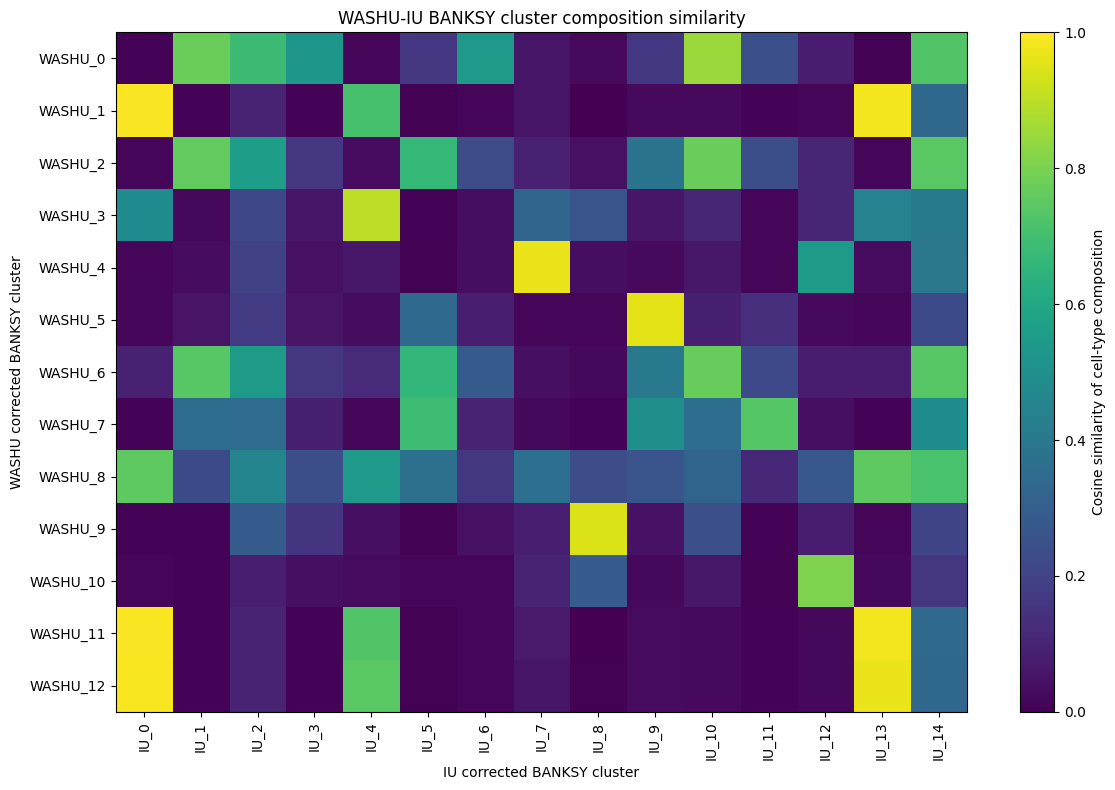

In [15]:
# confusion matrix

fig, ax = plt.subplots(figsize=(12, 8))

image = ax.imshow(composition_similarity.to_numpy(), aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(composition_similarity.shape[1]))
ax.set_xticklabels(composition_similarity.columns, rotation=90)
ax.set_yticks(range(composition_similarity.shape[0]))
ax.set_yticklabels(composition_similarity.index)

ax.set_xlabel("IU corrected BANKSY cluster")
ax.set_ylabel("WASHU corrected BANKSY cluster")
ax.set_title("WASHU-IU BANKSY cluster composition similarity")

fig.colorbar(image, ax=ax).set_label("Cosine similarity of cell-type composition")
fig.tight_layout()

fig.savefig(TABLE_DIR / "WASHU_IU_cluster_similarity.png", dpi=300, bbox_inches="tight")
fig.savefig(TABLE_DIR / "WASHU_IU_cluster_similarity.pdf", bbox_inches="tight")
plt.show()

In [16]:
# top matches

def get_top_cross_cohort_matches(similarity, top_n=3):
    long_table = (
        similarity
        .rename_axis("WASHUCluster")
        .reset_index()
        .melt(id_vars="WASHUCluster", var_name="IUCluster", value_name="CosineSimilarity")
        .sort_values(["WASHUCluster", "CosineSimilarity"], ascending=[True, False])
    )

    top_matches = (
        long_table
        .groupby("WASHUCluster", sort=False, group_keys=False)
        .head(top_n)
        .copy()
    )

    top_matches["MatchRank"] = top_matches.groupby("WASHUCluster", sort=False).cumcount() + 1

    return top_matches[["WASHUCluster", "MatchRank", "IUCluster", "CosineSimilarity"]]


def build_reciprocal_match_table(similarity):
    """For each WashU cluster: best IU match, runner-up, and whether the match is mutual."""
    best_washu_for_iu = similarity.idxmax(axis=0)

    rows = []
    for washu_cluster in similarity.index:
        ranked = similarity.loc[washu_cluster].sort_values(ascending=False)

        best_iu, best_score = ranked.index[0], ranked.iloc[0]

        if len(ranked) > 1:
            second_iu, second_score = ranked.index[1], ranked.iloc[1]
        else:
            second_iu, second_score = pd.NA, np.nan

        rows.append({
            "WASHUCluster": washu_cluster,
            "BestIUCluster": best_iu,
            "BestSimilarity": best_score,
            "SecondIUCluster": second_iu,
            "SecondSimilarity": second_score,
            "BestMinusSecond": best_score - second_score,
            "ReciprocalBestMatch": best_washu_for_iu[best_iu] == washu_cluster,
        })

    return pd.DataFrame(rows)


top_three_matches = get_top_cross_cohort_matches(composition_similarity, top_n=3)
reciprocal_matches = build_reciprocal_match_table(composition_similarity)

display(top_three_matches)
display(reciprocal_matches)

,WASHUCluster,MatchRank,IUCluster,CosineSimilarity
130,WASHU_0,1,IU_10,0.848997
13,WASHU_0,2,IU_1,0.774992
182,WASHU_0,3,IU_14,0.728041
1,WASHU_1,1,IU_0,0.995435
170,WASHU_1,2,IU_13,0.982781
53,WASHU_1,3,IU_4,0.708500
166,WASHU_10,1,IU_12,0.805060
114,WASHU_10,2,IU_8,0.287017
192,WASHU_10,3,IU_14,0.158957
11,WASHU_11,1,IU_0,0.995022


,WASHUCluster,BestIUCluster,BestSimilarity,SecondIUCluster,SecondSimilarity,BestMinusSecond,ReciprocalBestMatch
0,WASHU_0,IU_10,0.848997,IU_1,0.774992,0.074006,True
1,WASHU_1,IU_0,0.995435,IU_13,0.982781,0.012654,True
2,WASHU_2,IU_10,0.773001,IU_1,0.758253,0.014748,False
3,WASHU_3,IU_4,0.898658,IU_0,0.486103,0.412554,True
4,WASHU_4,IU_7,0.970342,IU_12,0.544660,0.425682,True
5,WASHU_5,IU_9,0.958366,IU_5,0.342399,0.615967,True
6,WASHU_6,IU_10,0.768327,IU_14,0.740844,0.027483,False
7,WASHU_7,IU_11,0.734550,IU_5,0.690946,0.043605,True
8,WASHU_8,IU_0,0.753577,IU_13,0.751320,0.002256,False
9,WASHU_9,IU_8,0.948383,IU_2,0.291341,0.657042,True


In [17]:
# save

washu_profile.to_csv(TABLE_DIR / "WASHU_cluster_celltype_profiles.csv")
iu_profile.to_csv(TABLE_DIR / "IU_cluster_celltype_profiles.csv")
composition_similarity.to_csv(TABLE_DIR / "WASHU_IU_cluster_similarity.csv")
top_three_matches.to_csv(TABLE_DIR / "WASHU_IU_top_three_matches.csv", index=False)
reciprocal_matches.to_csv(TABLE_DIR / "WASHU_IU_reciprocal_matches.csv", index=False)

print(f"Cross-cohort similarity results saved to {TABLE_DIR}")

Cross-cohort similarity results saved to results/atlasv2_corrected_banksy_tables


In [18]:
# add spatial coords to data

def attach_banksy_spatial_coordinates(
    integrated,
    banksy,
    cohort_name,
    coordinate_cols=("x_centroid", "y_centroid"),
):
    missing = [col for col in coordinate_cols if col not in banksy.obs.columns]
    if missing:
        raise KeyError(f"{cohort_name}: BANKSY object is missing {missing}")

    missing_cells = integrated.obs_names.difference(banksy.obs_names)
    if len(missing_cells):
        raise ValueError(
            f"{cohort_name}: {len(missing_cells):,} integrated cells are absent "
            "from the BANKSY object."
        )

    banksy_obs_aligned = banksy.obs.reindex(integrated.obs_names)

    for col in coordinate_cols:
        values = pd.to_numeric(banksy_obs_aligned[col], errors="coerce")

        if values.isna().any():
            raise ValueError(
                f"{cohort_name}: {values.isna().sum():,} cells have missing or "
                f"nonnumeric {col}."
            )

        integrated.obs[col] = values

    integrated.obsm["spatial"] = (
        integrated.obs[list(coordinate_cols)].to_numpy(dtype=float)
    )

    print(f"{cohort_name}: spatial coordinates attached to {integrated.n_obs:,} cells.")
    return integrated


washu = attach_banksy_spatial_coordinates(washu, washu_banksy, "WASHU")
iu = attach_banksy_spatial_coordinates(iu, iu_banksy, "IU")

assert washu.obs[["x_centroid", "y_centroid"]].notna().all().all()
assert iu.obs[["x_centroid", "y_centroid"]].notna().all().all()

WASHU: spatial coordinates attached to 60,956 cells.
IU: spatial coordinates attached to 342,597 cells.


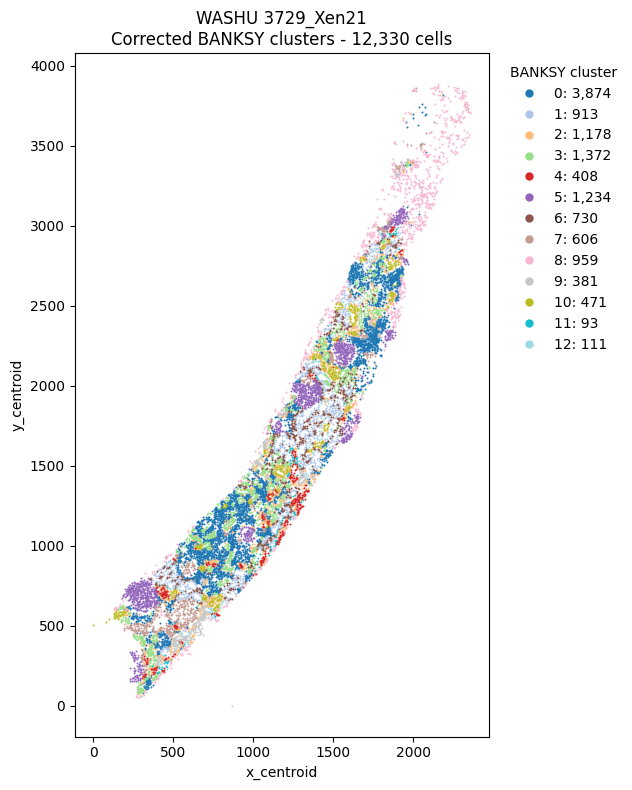

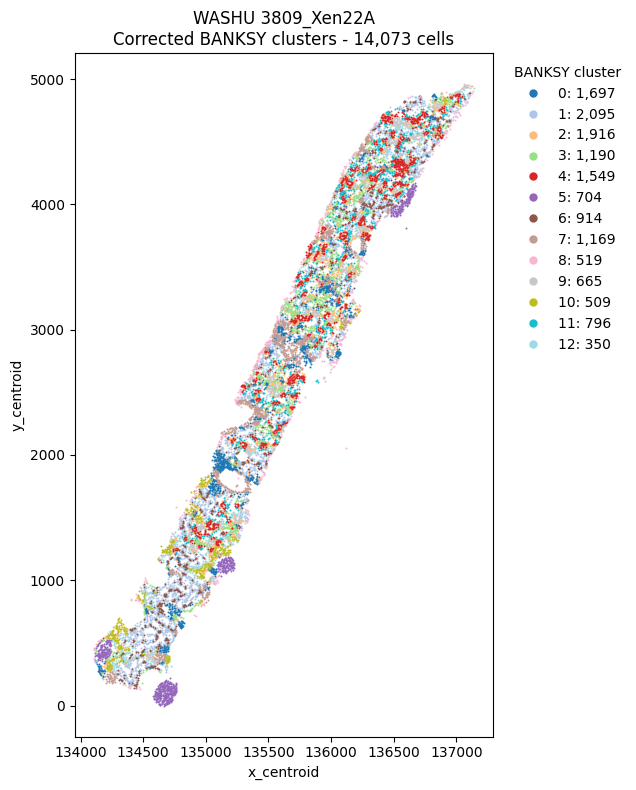

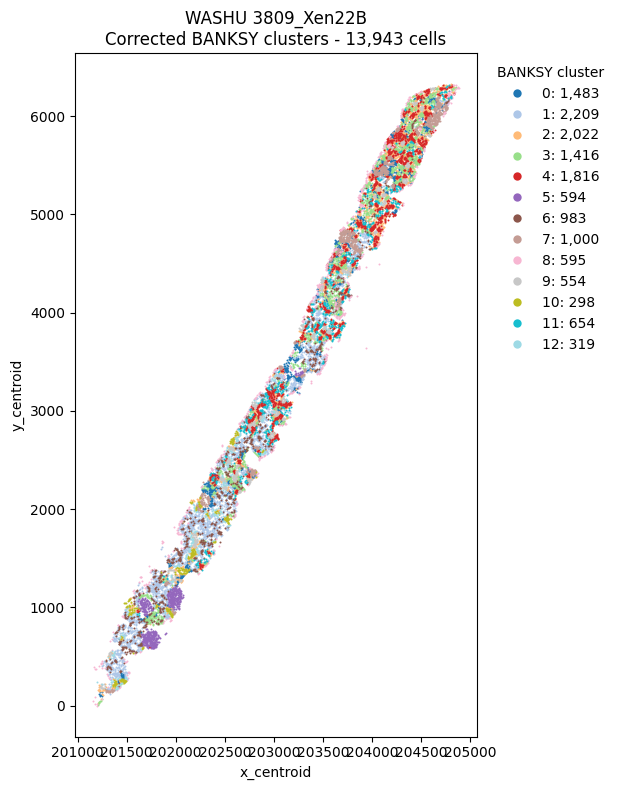

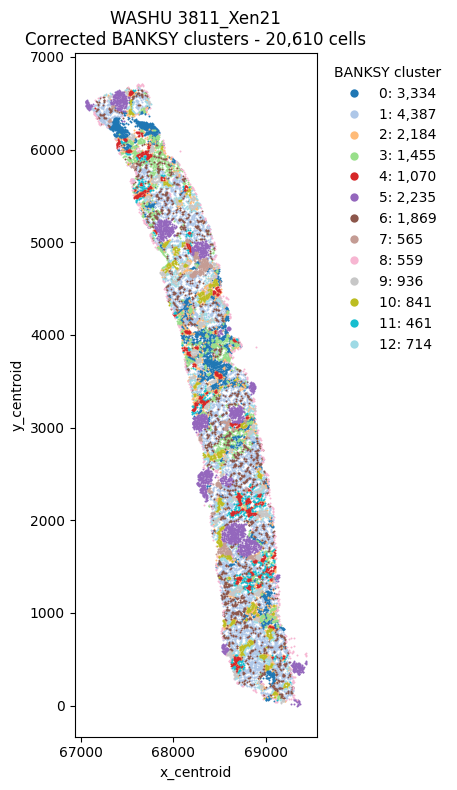

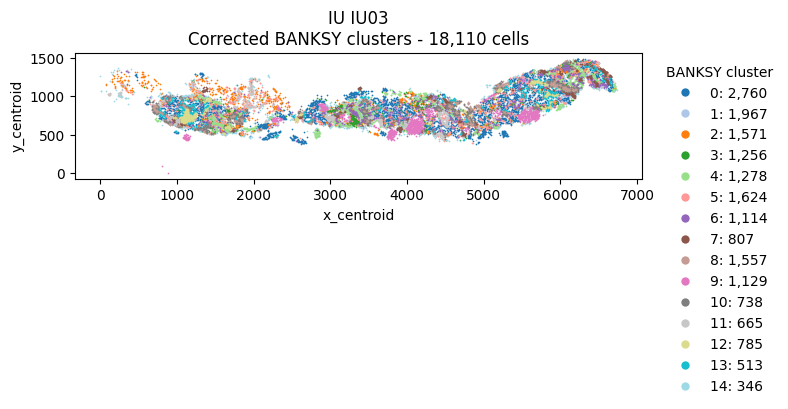

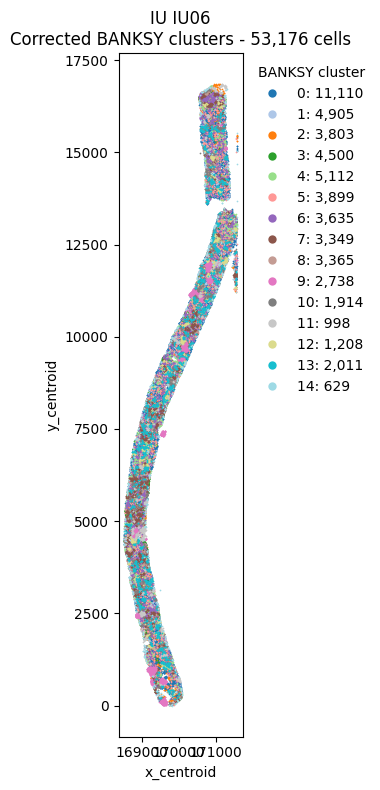

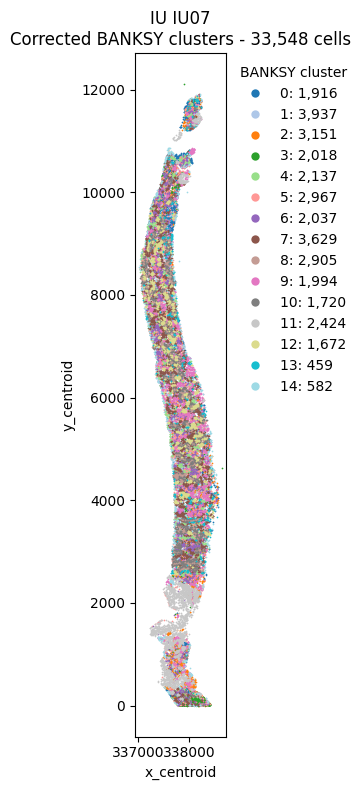

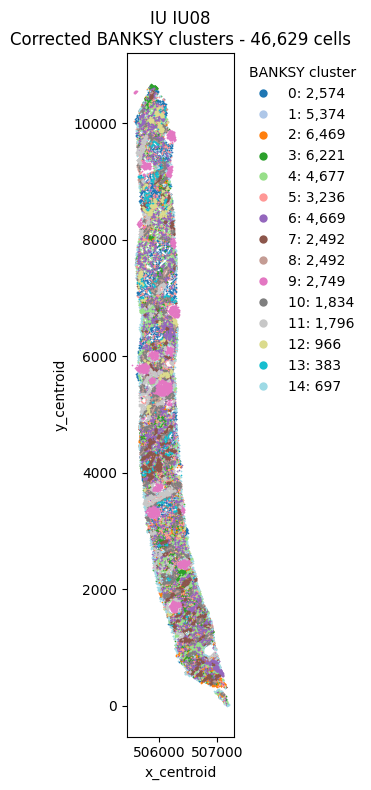

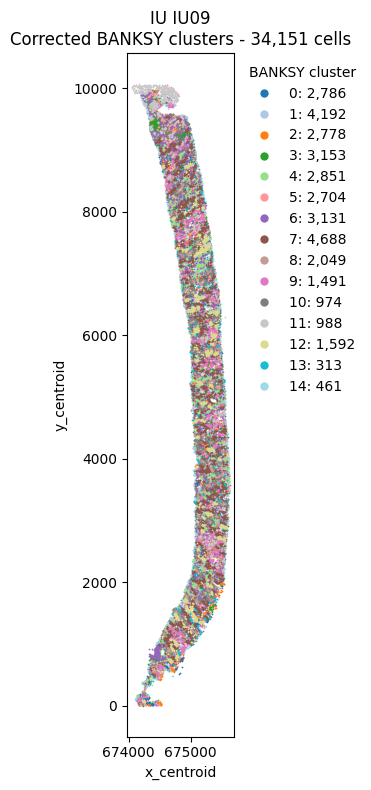

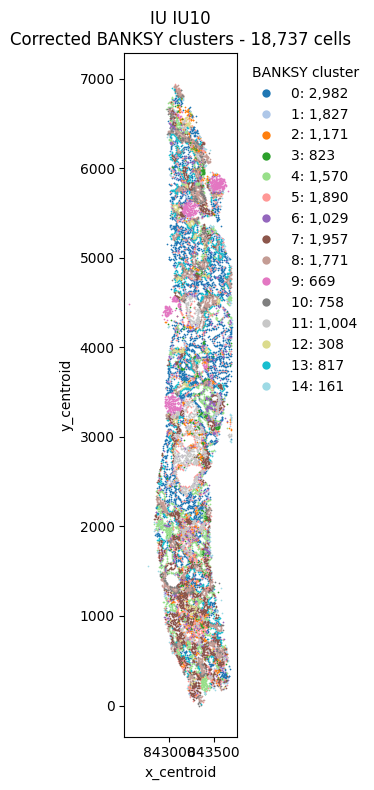

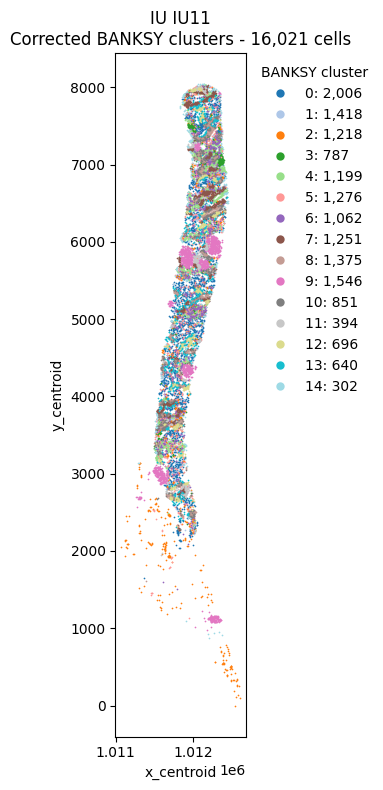

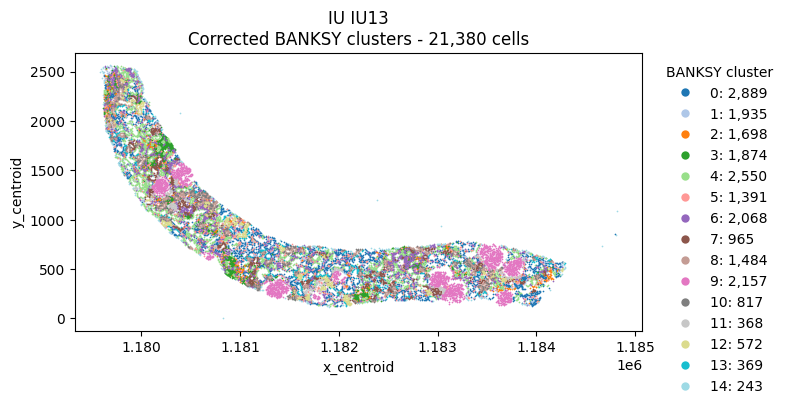

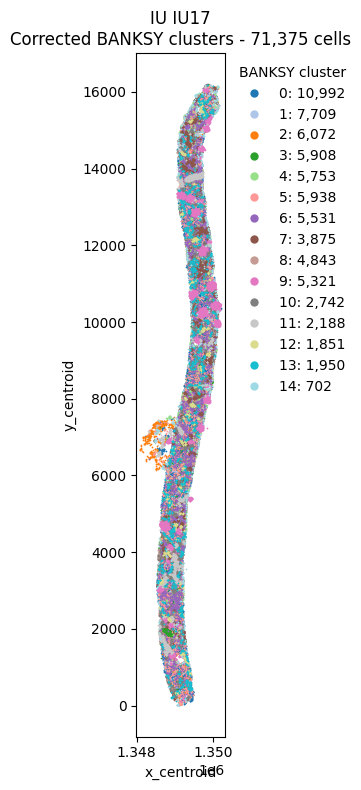

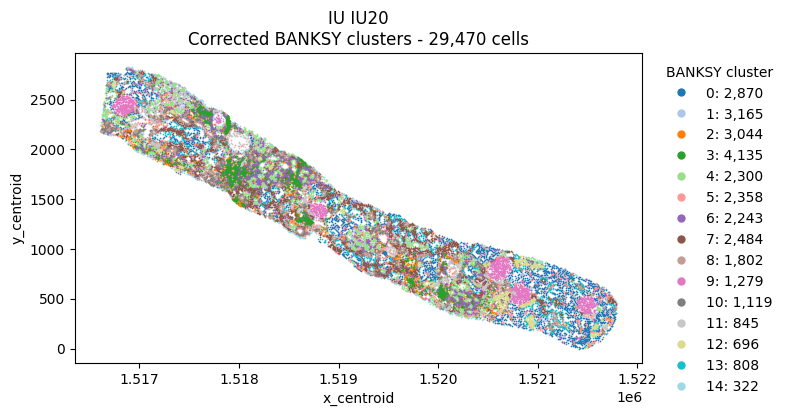

In [19]:
# spatial plots

def plot_banksy_clusters_by_sample(
    adata,
    cohort_name,
    sample_col=SAMPLE_COL,
    cluster_col=CLUSTER_COL,
    x_col="x_centroid",
    y_col="y_centroid",
    output_dir=None,
    point_size=2,
    invert_y=False,
    show=True,
):
    """One spatial map per sample, sharing a single cohort-level cluster palette."""
    output_dir = Path(output_dir) if output_dir is not None else SPATIAL_DIR

    required = [sample_col, cluster_col, x_col, y_col]
    missing = [col for col in required if col not in adata.obs.columns]
    if missing:
        raise KeyError(f"{cohort_name}: missing columns {missing}")

    obs = adata.obs[required].copy()
    obs[cluster_col] = obs[cluster_col].astype(str)
    obs[sample_col] = obs[sample_col].astype(str)

    # Palette is built once from all clusters in the cohort, so colors stay
    # consistent even for samples that lack some clusters.
    cluster_order, palette = make_cluster_palette(obs[cluster_col])

    cohort_dir = output_dir / cohort_name
    cohort_dir.mkdir(parents=True, exist_ok=True)

    for sample in natural_sort(obs[sample_col]):
        sample_obs = obs.loc[obs[sample_col] == sample]

        fig, ax = plt.subplots(figsize=(8, 8))

        for cluster in cluster_order:
            cluster_obs = sample_obs.loc[sample_obs[cluster_col] == cluster]
            if cluster_obs.empty:
                continue

            ax.scatter(
                cluster_obs[x_col], cluster_obs[y_col],
                s=point_size, c=[palette[cluster]],
                linewidths=0, rasterized=True,
            )

        ax.set_title(
            f"{cohort_name} {sample}\n"
            f"Corrected BANKSY clusters - {len(sample_obs):,} cells"
        )
        ax.set_aspect("equal")
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)

        if invert_y:
            ax.invert_yaxis()

        handles = [
            Line2D([0], [0], marker="o", linestyle="",
                   markerfacecolor=palette[cluster], markeredgecolor="none",
                   markersize=6,
                   label=f"{cluster}: {(sample_obs[cluster_col] == cluster).sum():,}")
            for cluster in cluster_order
            if (sample_obs[cluster_col] == cluster).any()
        ]

        ax.legend(handles=handles, title="BANKSY cluster",
                  bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

        fig.tight_layout()
        fig.savefig(cohort_dir / f"{cohort_name}_{sample}_BANKSY_clusters.png",
                    dpi=300, bbox_inches="tight")

        if show:
            plt.show()
        plt.close(fig)

    return palette


washu_cluster_palette = plot_banksy_clusters_by_sample(washu, "WASHU", point_size=2)
iu_cluster_palette = plot_banksy_clusters_by_sample(iu, "IU", point_size=1.5)

In [20]:
# panel maps

FULL_PANEL_MAP = OrderedDict({
    "Glom": [
        "EC-GC", "MC", "PEC", "POD", "altPOD",
    ],
    "PT / Thin limb": [
        "PT", "altPT",
        "ATL", "altATL",
        "DTL", "altDTL",
    ],
    "Distal nephron / CD": [
        "MD",
        "TAL", "altTAL",
        "DCT", "altDCT",
        "CNT", "altCNT",
        "PC", "altPC",
        "IC", "altIC",
    ],
    "Immune": [
        "B", "DC", "MAC", "MAST", "MON", "N", "NK", "PL", "T",
        "moMAC", "moMAC-INF", "resMAC",
    ],
    "Stromal / Mural": [
        "FIB", "altFIB", "infFIB", "pvFIB",
        "MYOF", "VSMC", "VSMC_P", "REN",
    ],
    "EC": [
        "EC",
    ],
    "Other": [
        "ERY", "SC_NEU",
    ],
})

# NOTE: the compact map deliberately omits "MAC" (and the thin-limb, DCT/CNT/CD and Other groups) relative to FULL_PANEL_MAP
# this is the map used for the published figure; do not add labels here without regenerating the figure and its source data
COMPACT_PANEL_MAP = OrderedDict({
    "Glom": [
        "EC-GC", "MC", "PEC", "POD", "altPOD",
    ],
    "PT": [
        "PT", "altPT",
    ],
    "TAL": [
        "MD", "TAL", "altTAL",
    ],
    "Immune": [
        "B", "DC", "MAST", "MON", "N", "NK", "PL", "T",
        "moMAC", "moMAC-INF", "resMAC",
    ],
    "Stromal": [
        "FIB", "MYOF", "REN", "VSMC", "VSMC_P",
        "altFIB", "infFIB", "pvFIB",
    ],
    "EC": [
        "EC",
    ],
})

In [21]:
# check ampping

def validate_panel_map(annotation_values, panel_map, map_name="panel map", require_complete=True):
    """Check a panel map against the annotations actually present in the data."""
    present = set(pd.Series(annotation_values).dropna().astype(str))

    mapped_list = [
        annotation
        for annotations in panel_map.values()
        for annotation in annotations
    ]
    mapped = set(mapped_list)

    duplicated = sorted({a for a in mapped_list if mapped_list.count(a) > 1})
    unmapped = sorted(present - mapped)
    unused = sorted(mapped - present)

    print(f"\n{map_name}")
    print(f"Present annotations: {len(present)}")
    print(f"Mapped annotations:  {len(mapped)}")
    print("\nUnmapped present annotations:", unmapped)
    print("Mapped but not present:      ", unused)
    print("Mapped more than once:       ", duplicated)

    if duplicated:
        raise ValueError(f"{map_name} maps annotations more than once: {duplicated}")

    if require_complete and unmapped:
        raise ValueError(f"{map_name} is missing annotations: {unmapped}")

    return {"unmapped": unmapped, "unused": unused, "duplicated": duplicated}


full_validation = validate_panel_map(
    all_present_annotations, FULL_PANEL_MAP,
    map_name="FULL_PANEL_MAP", require_complete=True,
)

compact_validation = validate_panel_map(
    all_present_annotations, COMPACT_PANEL_MAP,
    map_name="COMPACT_PANEL_MAP", require_complete=False,
)

print("\nAnnotations excluded from the compact figure:")
print(compact_validation["unmapped"])


FULL_PANEL_MAP
Present annotations: 45
Mapped annotations:  45

Unmapped present annotations: []
Mapped but not present:       []
Mapped more than once:        []

COMPACT_PANEL_MAP
Present annotations: 45
Mapped annotations:  30

Unmapped present annotations: ['ATL', 'CNT', 'DCT', 'DTL', 'ERY', 'IC', 'MAC', 'PC', 'SC_NEU', 'altATL', 'altCNT', 'altDCT', 'altDTL', 'altIC', 'altPC']
Mapped but not present:       []
Mapped more than once:        []

Annotations excluded from the compact figure:
['ATL', 'CNT', 'DCT', 'DTL', 'ERY', 'IC', 'MAC', 'PC', 'SC_NEU', 'altATL', 'altCNT', 'altDCT', 'altDTL', 'altIC', 'altPC']


In [22]:
# build bubble plot

def filter_panel_map(panel_map, present_annotations):
    """Drop panel entries that are absent from the current table."""
    present_annotations = set(map(str, present_annotations))

    filtered = OrderedDict()
    for panel, annotations in panel_map.items():
        keep = [a for a in annotations if a in present_annotations]
        if keep:
            filtered[panel] = keep

    return filtered


def build_bubble_plot_table(cluster_annotation, panel_map):
    """Dense cluster x annotation table with panel assignment, ready to plot."""
    required = {"Cluster", "Annotation", "Count", "FractionOfCluster", "FractionOfAnnotation"}
    missing = required - set(cluster_annotation.columns)
    if missing:
        raise KeyError(f"cluster_annotation table is missing columns: {sorted(missing)}")

    df = cluster_annotation.copy()
    df["Cluster"] = df["Cluster"].astype(str)
    df["Annotation"] = df["Annotation"].astype(str)

    filtered_panel_map = filter_panel_map(panel_map, sorted(df["Annotation"].unique()))

    annotation_to_panel = {}
    ordered_annotations = []
    for panel, annotations in filtered_panel_map.items():
        for annotation in annotations:
            annotation_to_panel[annotation] = panel
            ordered_annotations.append(annotation)

    df = df.loc[df["Annotation"].isin(ordered_annotations)].copy()
    cluster_order = natural_sort(df["Cluster"].unique())

    dense = pd.MultiIndex.from_product(
        [cluster_order, ordered_annotations],
        names=["Cluster", "Annotation"],
    ).to_frame(index=False)

    plot_df = dense.merge(
        df[["Cluster", "Annotation", "Count", "FractionOfCluster", "FractionOfAnnotation"]],
        on=["Cluster", "Annotation"],
        how="left",
        validate="one_to_one",
    )

    plot_df["Count"] = plot_df["Count"].fillna(0).astype(int)
    plot_df["FractionOfCluster"] = plot_df["FractionOfCluster"].fillna(0.0)
    plot_df["FractionOfAnnotation"] = plot_df["FractionOfAnnotation"].fillna(0.0)
    plot_df["Panel"] = plot_df["Annotation"].map(annotation_to_panel)

    return plot_df, filtered_panel_map, cluster_order

In [23]:
# build bubble plot

def draw_cohort_bubble_row(
    fig,
    subplot_spec,
    plot_df,
    panel_map,
    cluster_order,
    cluster_palette,
    cohort_name,
    total_samples,
    total_cells,
    metric_col="FractionOfAnnotation",
    size_scale=550,
    panel_title_fontsize=14,
    x_tick_fontsize=11,
    y_tick_fontsize=12,
    axis_label_fontsize=13,
    cohort_title_fontsize=15,
):
    """Draw all biological panels for one cohort as a row of shared-y subplots."""
    panels = list(panel_map.keys())

    # Panel widths track the number of annotations, so bubble spacing is uniform.
    inner = GridSpecFromSubplotSpec(
        1, len(panels),
        subplot_spec=subplot_spec,
        width_ratios=[max(len(panel_map[panel]), 1) for panel in panels],
        wspace=0.10,
    )

    y_map = {cluster: index for index, cluster in enumerate(cluster_order)}
    axes = []

    for panel_index, panel in enumerate(panels):
        ax = fig.add_subplot(inner[0, panel_index], sharey=axes[0] if axes else None)
        axes.append(ax)

        panel_annotations = panel_map[panel]
        x_map = {annotation: i for i, annotation in enumerate(panel_annotations)}

        sub = plot_df.loc[plot_df["Panel"] == panel].copy()
        sub["x"] = sub["Annotation"].map(x_map)
        sub["y"] = sub["Cluster"].map(y_map)

        # Skip empty combinations so absence reads as blank, not as a dot.
        nonzero = sub[metric_col] > 0

        ax.scatter(
            sub.loc[nonzero, "x"],
            sub.loc[nonzero, "y"],
            s=sub.loc[nonzero, metric_col] * size_scale,
            c=sub.loc[nonzero, "Cluster"].map(cluster_palette).tolist(),
            alpha=0.85,
            edgecolors="black",
            linewidths=0.25,
        )

        ax.set_xlim(-0.5, len(panel_annotations) - 0.5)
        ax.set_ylim(-0.5, len(cluster_order) - 0.5)
        ax.set_xticks(range(len(panel_annotations)))
        ax.set_xticklabels(panel_annotations, rotation=90, fontsize=x_tick_fontsize)
        ax.set_title(panel, fontsize=panel_title_fontsize, fontweight="medium", pad=8)
        ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.45)
        ax.set_axisbelow(True)
        ax.tick_params(axis="x", labelsize=x_tick_fontsize)

        if panel_index == 0:
            ax.set_yticks(range(len(cluster_order)))
            ax.set_yticklabels(cluster_order, fontsize=y_tick_fontsize)
            ax.set_ylabel("BANKSY Cluster", fontsize=axis_label_fontsize)
        else:
            ax.tick_params(axis="y", labelleft=False)

    axes[len(axes) // 2].text(
        0.5, 1.20,
        f"{cohort_name}\nTotal Samples: {total_samples}\nTotal Cells: {total_cells:,}",
        transform=axes[len(axes) // 2].transAxes,
        ha="center", va="bottom",
        fontsize=cohort_title_fontsize, fontweight="bold", linespacing=1.15,
    )

    return axes


def add_size_legend(
    fig,
    size_scale,
    values=(0.10, 0.25, 0.50, 0.75),
    title="Fraction of annotation",
    legend_fontsize=11,
    legend_title_fontsize=12,
):
    """Bubble-size legend using the same size_scale as the plotted bubbles."""
    handles = [
        plt.scatter([], [], s=value * size_scale, facecolor="gray",
                    edgecolor="black", linewidth=0.3, alpha=0.7)
        for value in values
    ]

    legend = fig.legend(
        handles, [f"{value:.0%}" for value in values],
        title=title, loc="upper right", bbox_to_anchor=(0.995, 0.94),
        frameon=False, labelspacing=1.1, fontsize=legend_fontsize,
    )

    legend.get_title().set_fontsize(legend_title_fontsize)

In [24]:
# build bubble plot 

def plot_two_cohort_bubble_figure(
    washu_cluster_annotation,
    iu_cluster_annotation,
    washu_obs,
    iu_obs,
    panel_map,
    figure_title,
    output_prefix,
    metric_col="FractionOfAnnotation",
    size_scale=550,
    figsize=(28, 10),
    main_title_fontsize=20,
    panel_title_fontsize=14,
    x_tick_fontsize=11,
    y_tick_fontsize=12,
    axis_label_fontsize=13,
    cohort_title_fontsize=15,
    legend_fontsize=11,
    legend_title_fontsize=12,
    return_tables=False,
):
    """
    Draw WASHU and IU bubble plots side by side and save PNG + PDF.

    metric_col:
        FractionOfAnnotation - fraction of each cell type assigned to the cluster.
        FractionOfCluster    - cell-type composition of each cluster.

    Set return_tables=True to also get back the exact plotted values, which is
    what the source-data export in section 13 uses.
    """
    valid_metrics = {"FractionOfAnnotation", "FractionOfCluster"}
    if metric_col not in valid_metrics:
        raise ValueError(f"metric_col must be one of {sorted(valid_metrics)}")

    washu_plot_df, washu_panel_map, washu_cluster_order = build_bubble_plot_table(
        washu_cluster_annotation, panel_map,
    )
    iu_plot_df, iu_panel_map, iu_cluster_order = build_bubble_plot_table(
        iu_cluster_annotation, panel_map,
    )

    if washu_panel_map != iu_panel_map:
        raise ValueError(
            "WASHU and IU produced different filtered panel maps. "
            "Check whether their annotation vocabularies differ."
        )

    final_panel_map = washu_panel_map

    _, washu_palette = make_cluster_palette(washu_cluster_order)
    _, iu_palette = make_cluster_palette(iu_cluster_order)

    fig = plt.figure(figsize=figsize)
    outer = GridSpec(1, 2, figure=fig, width_ratios=[1, 1], wspace=0.10)

    common_draw_args = {
        "panel_map": final_panel_map,
        "metric_col": metric_col,
        "size_scale": size_scale,
        "panel_title_fontsize": panel_title_fontsize,
        "x_tick_fontsize": x_tick_fontsize,
        "y_tick_fontsize": y_tick_fontsize,
        "axis_label_fontsize": axis_label_fontsize,
        "cohort_title_fontsize": cohort_title_fontsize,
    }

    draw_cohort_bubble_row(
        fig=fig, subplot_spec=outer[0, 0], plot_df=washu_plot_df,
        cluster_order=washu_cluster_order, cluster_palette=washu_palette,
        cohort_name="WASHU",
        total_samples=washu_obs["Sample"].nunique(), total_cells=len(washu_obs),
        **common_draw_args,
    )

    draw_cohort_bubble_row(
        fig=fig, subplot_spec=outer[0, 1], plot_df=iu_plot_df,
        cluster_order=iu_cluster_order, cluster_palette=iu_palette,
        cohort_name="IU",
        total_samples=iu_obs["Sample"].nunique(), total_cells=len(iu_obs),
        **common_draw_args,
    )

    fig.suptitle(figure_title, fontsize=main_title_fontsize, fontweight="bold", y=0.99)

    add_size_legend(
        fig,
        size_scale=size_scale,
        values=(0.10, 0.25, 0.50, 0.75),
        title=("Fraction of annotation" if metric_col == "FractionOfAnnotation"
               else "Fraction of cluster"),
        legend_fontsize=legend_fontsize,
        legend_title_fontsize=legend_title_fontsize,
    )

    fig.subplots_adjust(left=0.045, right=0.925, bottom=0.28, top=0.76)

    output_prefix = Path(output_prefix)
    output_prefix.parent.mkdir(parents=True, exist_ok=True)

    png_path = output_prefix.with_suffix(".png")
    pdf_path = output_prefix.with_suffix(".pdf")

    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()

    print(f"Saved PNG: {png_path}")
    print(f"Saved PDF: {pdf_path}")

    if return_tables:
        return fig, {"WASHU": washu_plot_df, "IU": iu_plot_df}, final_panel_map

    return fig

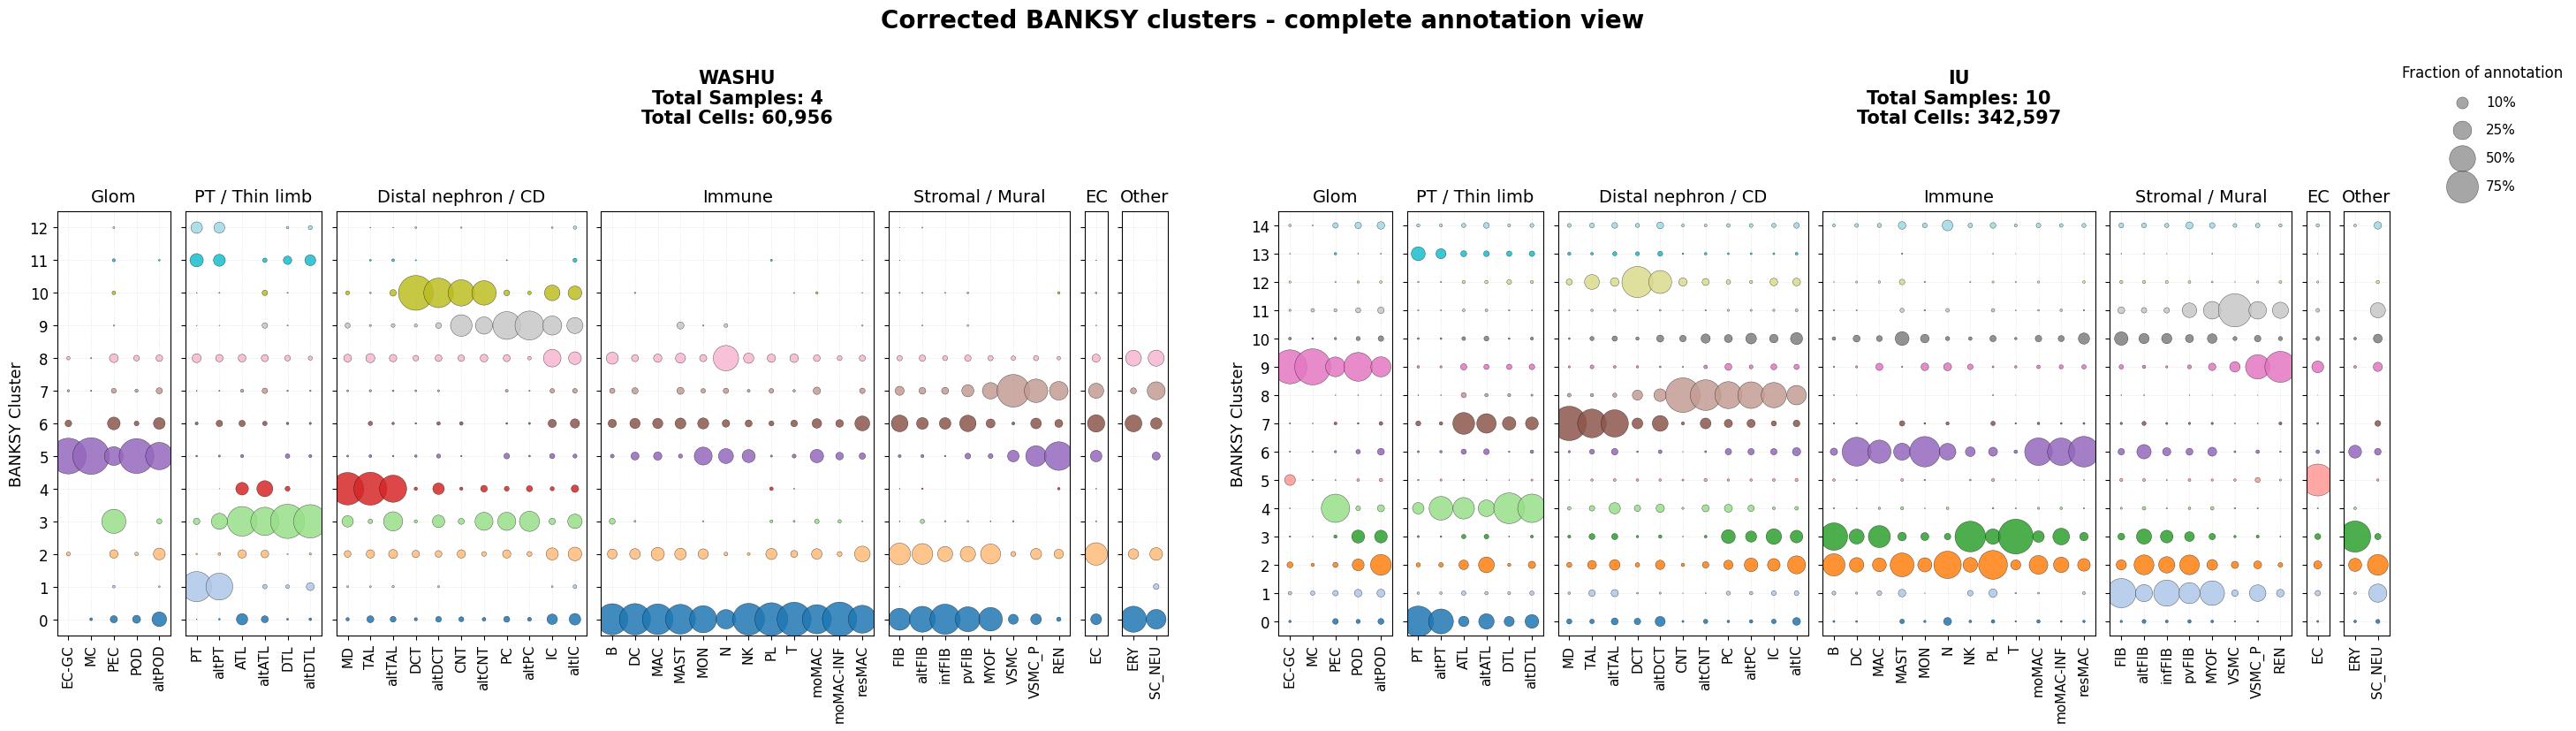

Saved PNG: results/corrected_banksy_tables/Corrected_BANKSY_bubble_complete.png
Saved PDF: results/corrected_banksy_tables/Corrected_BANKSY_bubble_complete.pdf


In [25]:
# figs with original cluster numbers

complete_fig = plot_two_cohort_bubble_figure(
    washu_cluster_annotation=washu_cluster_annotation,
    iu_cluster_annotation=iu_cluster_annotation,
    washu_obs=washu_obs,
    iu_obs=iu_obs,
    panel_map=FULL_PANEL_MAP,
    figure_title="Corrected BANKSY clusters - complete annotation view",
    output_prefix=FIGURE_DIR / "Corrected_BANKSY_bubble_complete",
    metric_col="FractionOfAnnotation",
    size_scale=900,
    figsize=(30, 10),
)

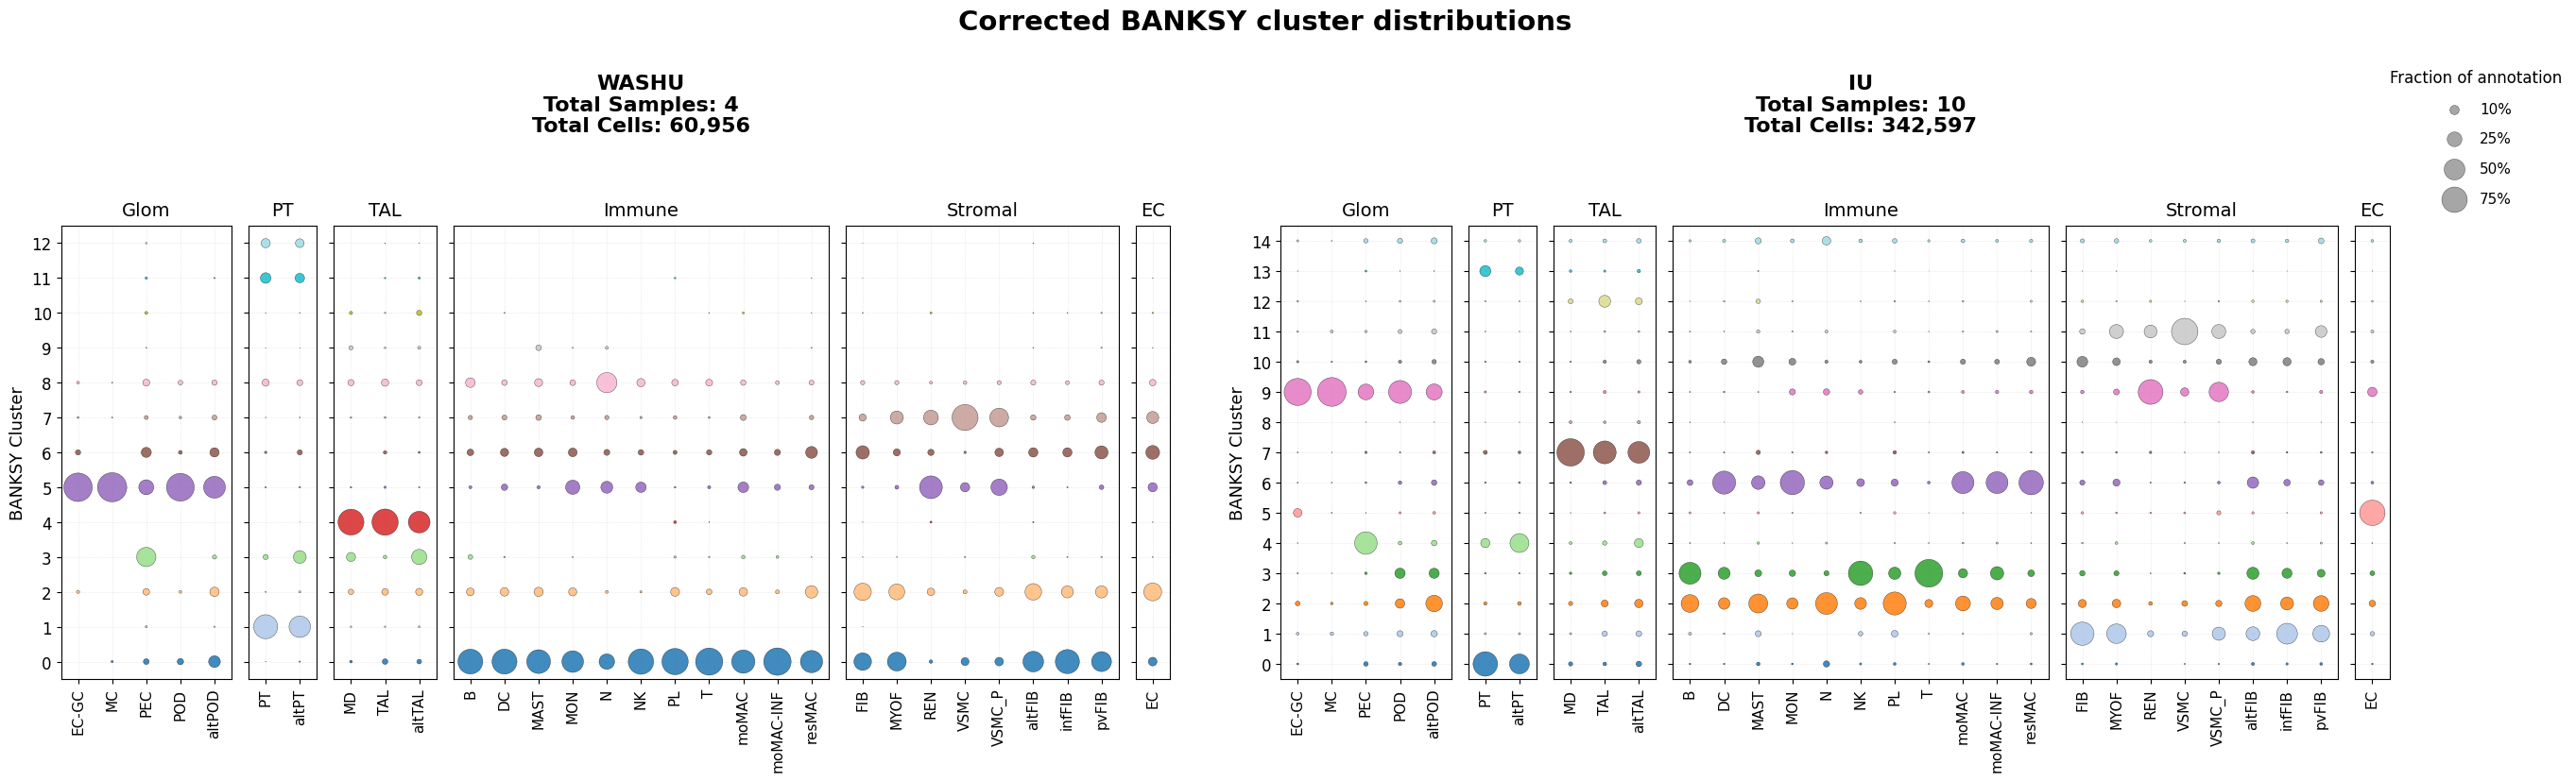

Saved PNG: results/corrected_banksy_tables/Corrected_BANKSY_bubble_compact.png
Saved PDF: results/corrected_banksy_tables/Corrected_BANKSY_bubble_compact.pdf


In [26]:
# smaller bubbles

compact_fig = plot_two_cohort_bubble_figure(
    washu_cluster_annotation=washu_cluster_annotation,
    iu_cluster_annotation=iu_cluster_annotation,
    washu_obs=washu_obs,
    iu_obs=iu_obs,
    panel_map=COMPACT_PANEL_MAP,
    figure_title="Corrected BANKSY cluster distributions",
    output_prefix=FIGURE_DIR / "Corrected_BANKSY_bubble_compact",
    metric_col="FractionOfAnnotation",
    size_scale=500,
    figsize=(28, 10),
    main_title_fontsize=21,
    cohort_title_fontsize=16,
)

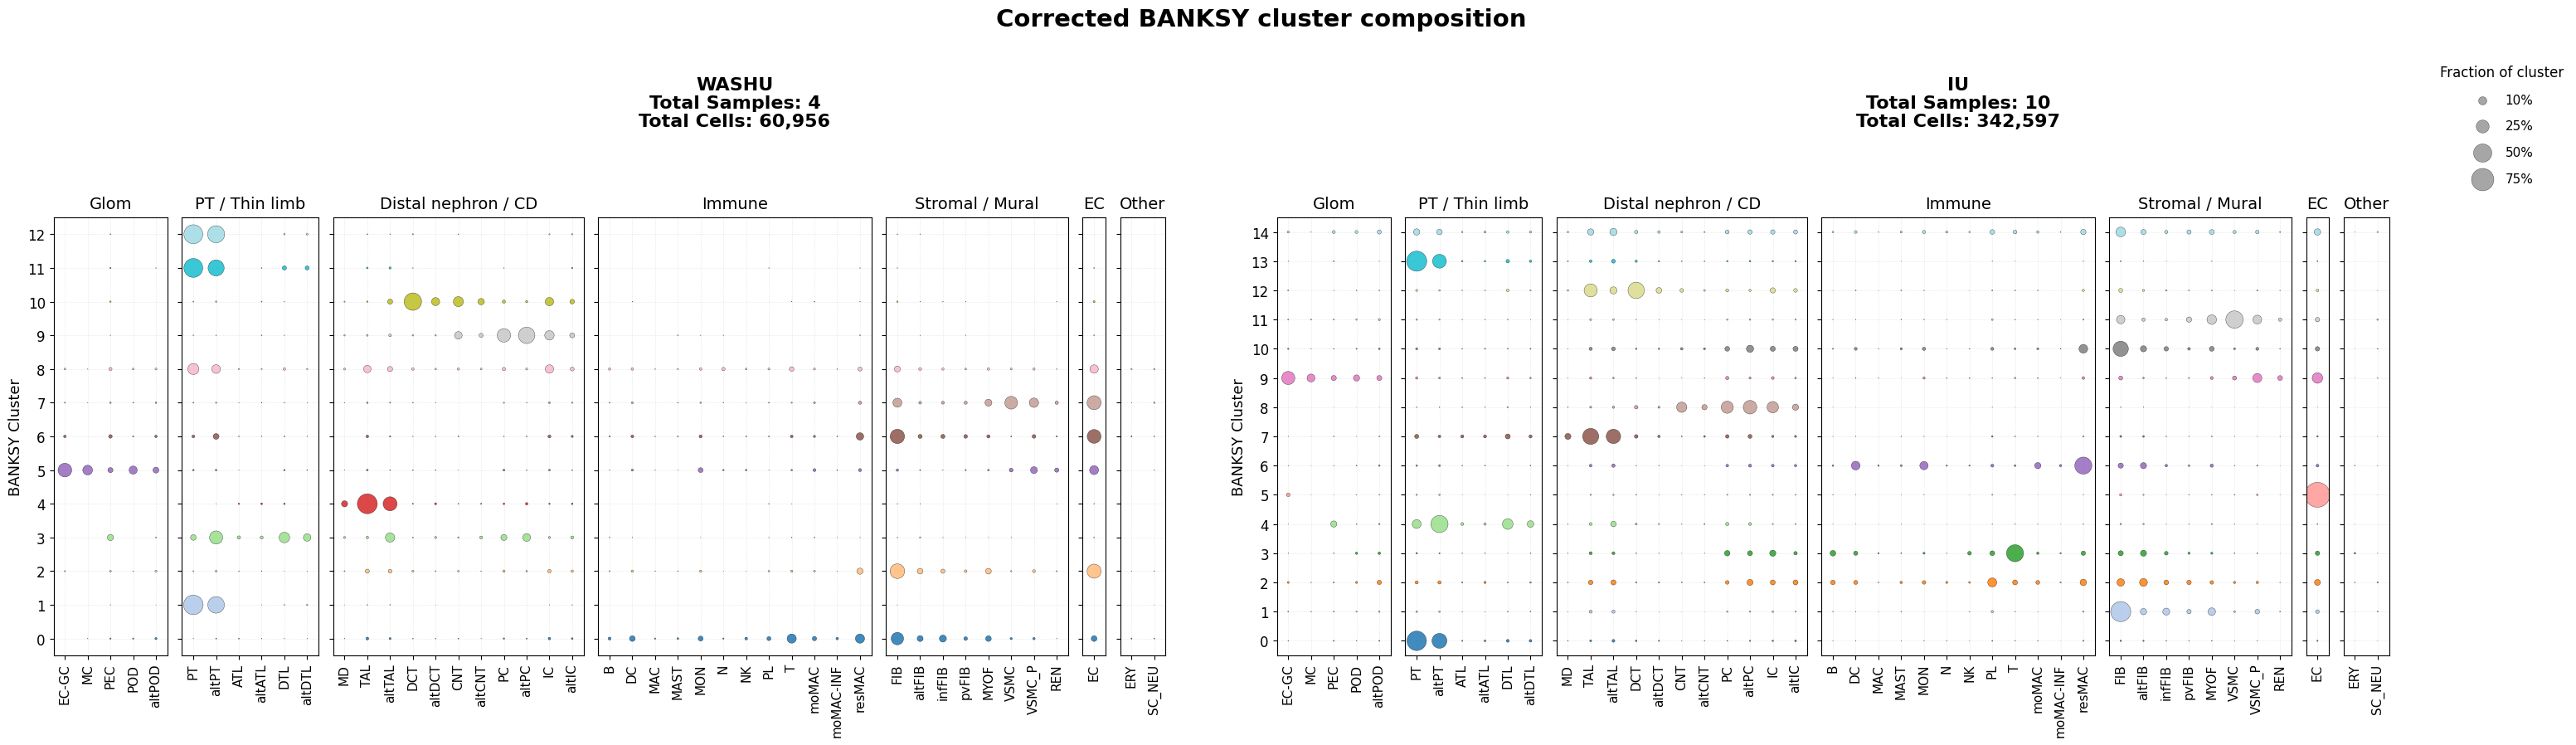

Saved PNG: results/corrected_banksy_tables/Corrected_BANKSY_fraction_of_cluster.png
Saved PDF: results/corrected_banksy_tables/Corrected_BANKSY_fraction_of_cluster.pdf


In [27]:
composition_fig = plot_two_cohort_bubble_figure(
    washu_cluster_annotation=washu_cluster_annotation,
    iu_cluster_annotation=iu_cluster_annotation,
    washu_obs=washu_obs,
    iu_obs=iu_obs,
    panel_map=FULL_PANEL_MAP,
    figure_title="Corrected BANKSY cluster composition",
    output_prefix=FIGURE_DIR / "Corrected_BANKSY_fraction_of_cluster",
    metric_col="FractionOfCluster",
    size_scale=500,
    figsize=(32, 11),
    main_title_fontsize=21,
    cohort_title_fontsize=16,
)

## Reassign BANKSY Cluster Numbers

### new BANKSY clusters assigned figure-specific niche identifiers based on dominant cell-type composition to preserve visual continuity with the original analysis; these display identifiers do not imply *direct equivalence* to the original min_counts=5 filtered clusters

In [28]:
# reassign cluster numbers

# corrected cluster -> display niche number
WASHU_DISPLAY_NICHE_MAP = {
    "0":  "2",   # fibroimmune
    "1":  "1",   # PT-rich A
    "2":  "0",   # fibrovascular / interstitial A
    "3":  "3",   # altered-PT / thin-limb
    "4":  "9",   # TAL / MD
    "5":  "5",   # glomerular
    "6":  "7",   # fibrovascular / interstitial B
    "7":  "8",   # vascular / mural
    "8":  "4",   # mixed niche
    "9":  "10",  # collecting duct
    "10": "6",   # DCT / distal nephron
    "11": "11",  # PT-rich B
    "12": "14",  # PT-rich C
}

IU_DISPLAY_NICHE_MAP = {
    "0":  "1",   # PT-rich A
    "1":  "0",   # fibrotic stromal
    "2":  "2",   # mixed immune-stromal
    "3":  "5",   # lymphoid-rich
    "4":  "15",  # altered-PT / thin-limb
    "5":  "4",   # endothelial
    "6":  "12",  # myeloid-rich
    "7":  "7",   # TAL / MD
    "8":  "10",  # collecting duct
    "9":  "9",   # glomerular
    "10": "11",  # fibro-inflammatory
    "11": "8",   # vascular / mural
    "12": "13",  # DCT / distal nephron
    "13": "3",   # PT-rich B
    "14": "14",  # mixed / unresolved
}

# Descriptive names, used for the Xenium Explorer selection export.
WASHU_NICHE_NAME_MAP = {
    "0":  "Fibroimmune",
    "1":  "PT-rich_A",
    "2":  "Fibrovascular_A",
    "3":  "Altered-PT_thin-limb",
    "4":  "TAL_MD",
    "5":  "Glomerular",
    "6":  "Fibrovascular_B",
    "7":  "Vascular_mural",
    "8":  "Mixed_distal-interstitial",
    "9":  "Collecting_duct",
    "10": "DCT_distal-nephron",
    "11": "PT-rich_B",
    "12": "PT-rich_C",
}

In [29]:
# cluster number crosswalk

def apply_display_niche_numbers(cluster_annotation, display_map, cohort_name):
    """
    Relabel Cluster with figure display numbers, keeping the original ID in
    CorrectedCluster. Raises if the map is not total or not injective.
    """
    result = cluster_annotation.copy()
    result["CorrectedCluster"] = result["Cluster"].astype(str)

    missing = sorted(set(result["CorrectedCluster"].unique()) - set(display_map))
    if missing:
        raise ValueError(
            f"{cohort_name}: display labels are missing for corrected clusters {missing}"
        )

    result["Cluster"] = result["CorrectedCluster"].map(display_map).astype(str)

    # Each corrected cluster must receive a unique display number.
    reverse = pd.Series(display_map).reset_index()
    reverse.columns = ["CorrectedCluster", "DisplayNiche"]

    duplicated = (
        reverse.loc[reverse["DisplayNiche"].duplicated(keep=False), "DisplayNiche"]
        .unique().tolist()
    )

    if duplicated:
        raise ValueError(
            f"{cohort_name}: multiple corrected clusters were assigned the same "
            f"display niche: {duplicated}"
        )

    return result


washu_cluster_annotation_display = apply_display_niche_numbers(
    washu_cluster_annotation, WASHU_DISPLAY_NICHE_MAP, "WASHU",
)

iu_cluster_annotation_display = apply_display_niche_numbers(
    iu_cluster_annotation, IU_DISPLAY_NICHE_MAP, "IU",
)


def build_display_crosswalk(display_map, cohort):
    return (
        pd.DataFrame({
            "Cohort": cohort,
            "CorrectedCluster": list(display_map.keys()),
            "DisplayNiche": list(display_map.values()),
        })
        .sort_values("DisplayNiche", key=lambda s: pd.to_numeric(s))
        .reset_index(drop=True)
    )


display_crosswalk = pd.concat([
    build_display_crosswalk(WASHU_DISPLAY_NICHE_MAP, "WASHU"),
    build_display_crosswalk(IU_DISPLAY_NICHE_MAP, "IU"),
], ignore_index=True)

display_crosswalk.to_csv(FIGURE_DIR / "display_niche_crosswalk.csv", index=False)
display(display_crosswalk)

,Cohort,CorrectedCluster,DisplayNiche
0,WASHU,2,0
1,WASHU,1,1
2,WASHU,0,2
3,WASHU,3,3
4,WASHU,8,4
5,WASHU,5,5
6,WASHU,10,6
7,WASHU,6,7
8,WASHU,7,8
9,WASHU,4,9


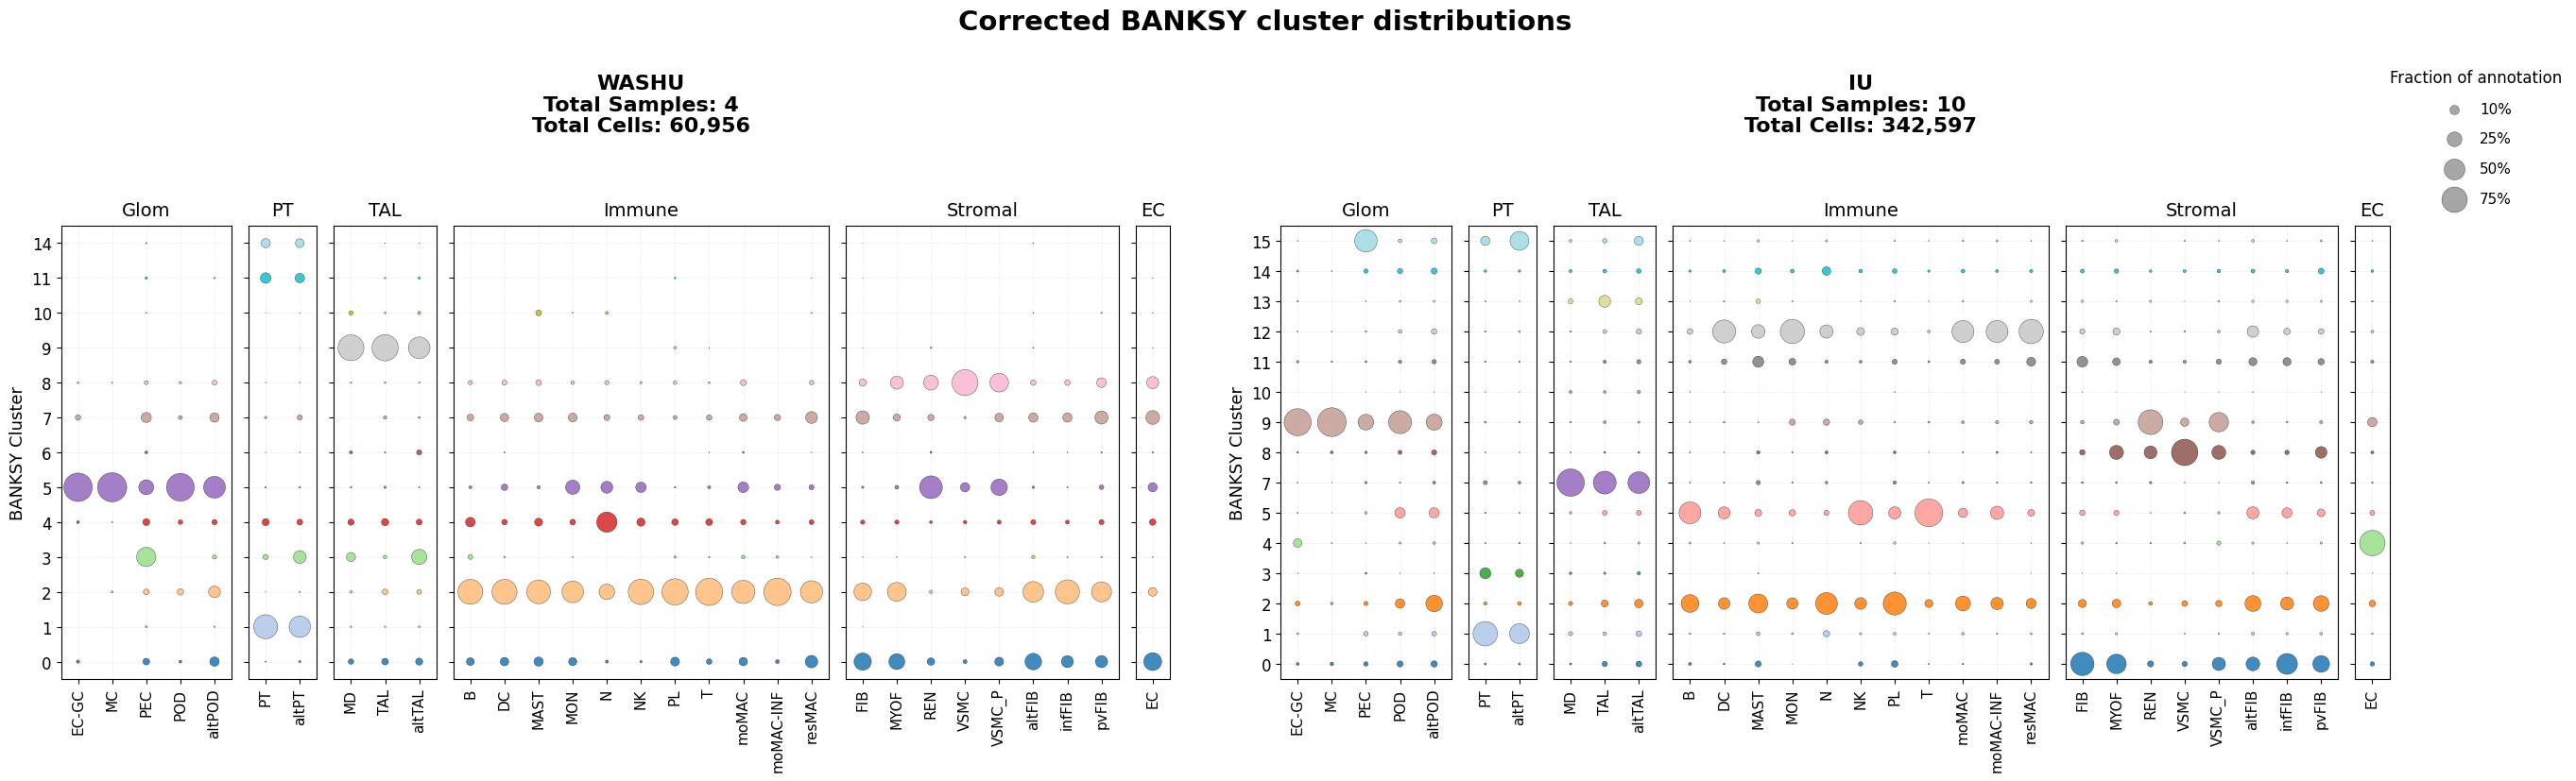

Saved PNG: results/corrected_banksy_tables/Corrected_BANKSY_compact_display_niche_numbers.png
Saved PDF: results/corrected_banksy_tables/Corrected_BANKSY_compact_display_niche_numbers.pdf


In [30]:
# final fig

compact_display_number_fig, bubble_plot_tables, bubble_panel_map = plot_two_cohort_bubble_figure(
    washu_cluster_annotation=washu_cluster_annotation_display,
    iu_cluster_annotation=iu_cluster_annotation_display,
    washu_obs=washu_obs,
    iu_obs=iu_obs,
    panel_map=COMPACT_PANEL_MAP,
    figure_title="Corrected BANKSY cluster distributions",
    output_prefix=FIGURE_DIR / "Corrected_BANKSY_compact_display_niche_numbers",
    metric_col="FractionOfAnnotation",

    size_scale=500,
    figsize=(28, 10),

    main_title_fontsize=21,
    cohort_title_fontsize=16,
    panel_title_fontsize=14,
    x_tick_fontsize=11,
    y_tick_fontsize=12,
    axis_label_fontsize=13,
    legend_fontsize=11,
    legend_title_fontsize=12,

    return_tables=True,
)

## Source Data

In [31]:
def build_source_data(plot_df, cluster_annotation_display, obs, cohort, metric_col):
    """Long-format source data for one cohort's bubbles."""
    crosswalk = (
        cluster_annotation_display[["Cluster", "CorrectedCluster"]]
        .drop_duplicates()
        .set_index("Cluster")["CorrectedCluster"]
    )

    src = plot_df.loc[plot_df[metric_col] > 0].copy()

    src.insert(0, "Cohort", cohort)
    src = src.rename(columns={
        "Cluster": "DisplayNiche",
        "Count": "nCellsAnnotationInCluster",
    })

    src.insert(2, "CorrectedCluster", src["DisplayNiche"].map(crosswalk))

    src["nCellsAnnotationTotal"] = (
        src["Annotation"].map(obs["Annotation"].value_counts())
    )
    src["nCellsClusterTotal"] = (
        src["nCellsAnnotationInCluster"] / src["FractionOfCluster"]
    ).round().astype(int)

    src["FractionOfAnnotation"] = src["FractionOfAnnotation"].round(6)
    src["FractionOfCluster"] = src["FractionOfCluster"].round(6)

    
    recomputed = src["nCellsAnnotationInCluster"] / src["nCellsAnnotationTotal"]
    max_error = (recomputed - src["FractionOfAnnotation"]).abs().max()
    if max_error > 1e-5:
        raise ValueError(f"{cohort}: FractionOfAnnotation does not match raw counts "
                         f"(max error {max_error:.2e})")

    order = {c: i for i, c in enumerate(natural_sort(src["DisplayNiche"]))}

    return (
        src[[
            "Cohort", "DisplayNiche", "CorrectedCluster", "Panel", "Annotation",
            "nCellsAnnotationInCluster", "nCellsAnnotationTotal", "nCellsClusterTotal",
            "FractionOfAnnotation", "FractionOfCluster",
        ]]
        .assign(_order=lambda d: d["DisplayNiche"].map(order))
        .sort_values(["_order", "Panel", "Annotation"])
        .drop(columns="_order")
        .reset_index(drop=True)
    )


source_data = pd.concat([
    build_source_data(bubble_plot_tables["WASHU"], washu_cluster_annotation_display,
                      washu_obs, "WASHU", "FractionOfAnnotation"),
    build_source_data(bubble_plot_tables["IU"], iu_cluster_annotation_display,
                      iu_obs, "IU", "FractionOfAnnotation"),
], ignore_index=True)

display(source_data.head(12))
print(f"\n{len(source_data):,} bubbles")

,Cohort,DisplayNiche,CorrectedCluster,Panel,Annotation,nCellsAnnotationInCluster,nCellsAnnotationTotal,nCellsClusterTotal,FractionOfAnnotation,FractionOfCluster
0,WASHU,0,2,EC,EC,2184,5866,7300,0.372315,0.299178
1,WASHU,0,2,Glom,EC-GC,17,1439,7300,0.011814,0.002329
2,WASHU,0,2,Glom,PEC,38,726,7300,0.052342,0.005205
3,WASHU,0,2,Glom,POD,5,533,7300,0.009381,0.000685
4,WASHU,0,2,Glom,altPOD,47,458,7300,0.102620,0.006438
5,WASHU,0,2,Immune,B,14,196,7300,0.071429,0.001918
6,WASHU,0,2,Immune,DC,58,694,7300,0.083573,0.007945
7,WASHU,0,2,Immune,MAST,8,81,7300,0.098765,0.001096
8,WASHU,0,2,Immune,MON,56,723,7300,0.077455,0.007671
9,WASHU,0,2,Immune,N,1,97,7300,0.010309,0.000137



674 bubbles


In [32]:
notes = pd.DataFrame({"Note": [
    "Bubble size encodes FractionOfAnnotation = nCellsAnnotationInCluster / "
    "nCellsAnnotationTotal, computed within cohort.",
    "FractionOfAnnotation sums to 1 across clusters within each cell type and cohort; "
    "values here are restricted to the annotations shown in the figure, so column sums "
    "may fall below 1 where a cell type also occurs in an unplotted cluster.",
    "FractionOfCluster is provided for reference and is not the plotted quantity.",
    "DisplayNiche is the figure label. CorrectedCluster is the BANKSY cluster ID in the "
    "deposited objects. See the 'Cluster renumbering' sheet.",
    "Panel indicates the sub-panel each cell type was plotted in.",
    "Cluster x cell type combinations with zero cells are omitted; a missing row is a "
    "true absence, not a suppressed zero.",
    "Bubble color encodes cluster identity only and carries no quantitative value.",
]})

source_data_path = SOURCE_DATA_DIR / "SourceData_BANKSY_bubble_plot.xlsx"

with pd.ExcelWriter(source_data_path) as writer:
    source_data.to_excel(writer, sheet_name="Bubble plot", index=False)
    display_crosswalk.to_excel(writer, sheet_name="Cluster renumbering", index=False)
    notes.to_excel(writer, sheet_name="Notes", index=False)

source_data.to_csv(SOURCE_DATA_DIR / "SourceData_BANKSY_bubble_plot.csv", index=False)

print(f"Source data written to {source_data_path}")

Source data written to results/source_data/SourceData_BANKSY_bubble_plot.xlsx


## Xen Explorer Export for Fig 4

In [33]:
def export_explorer_selections(
    adata,
    sample_id,
    display_map,
    name_map,
    export_dir,
    cluster_col=CLUSTER_COL,
    annotation_col=ANNOTATION_COL,
    sample_col=SAMPLE_COL,
    cell_id_col=CELL_ID_COL,
):
    export_dir = Path(export_dir)
    export_dir.mkdir(parents=True, exist_ok=True)

    required = [cell_id_col, sample_col, cluster_col, annotation_col]
    missing = [col for col in required if col not in adata.obs.columns]
    if missing:
        raise KeyError(f"Missing columns: {missing}")

    obs = adata.obs.loc[
        adata.obs[sample_col].astype(str).eq(sample_id), required
    ].copy()

    if obs.empty:
        raise ValueError(f"No cells found for sample {sample_id!r}")

    obs["CorrectedCluster"] = obs[cluster_col].astype(str)
    obs["DisplayNiche"] = obs["CorrectedCluster"].map(display_map)
    obs["NicheName"] = obs["CorrectedCluster"].map(name_map)

    assert obs[cell_id_col].astype(str).is_unique, "cell_id is not unique within the sample"
    assert obs["DisplayNiche"].notna().all(), "unmapped cluster in display_map"
    assert obs["NicheName"].notna().all(), "unmapped cluster in name_map"

    cell_ids = obs[cell_id_col].astype(str)

    exports = {
        "corrected_BANKSY_clusters": "BANKSY_C" + obs["CorrectedCluster"],
        "celltypes": obs[annotation_col].astype(str),
        "corrected_BANKSY_display_niches_named": (
            "N" + obs["DisplayNiche"] + "_" + obs["NicheName"] + "_C" + obs["CorrectedCluster"]
        ),
    }

    written = {}
    for suffix, group in exports.items():
        frame = pd.DataFrame({"cell_id": cell_ids, "group": group})
        path = export_dir / f"{sample_id}_{suffix}.csv"
        frame.to_csv(path, index=False)
        written[suffix] = frame
        print(f"{len(frame):>7,} cells -> {path}")

    return written


explorer_exports = export_explorer_selections(
    adata=washu,
    sample_id=EXPLORER_SAMPLE_ID,
    display_map=WASHU_DISPLAY_NICHE_MAP,
    name_map=WASHU_NICHE_NAME_MAP,
    export_dir=EXPLORER_DIR,
)

display(explorer_exports["corrected_BANKSY_display_niches_named"].head())
print(explorer_exports["corrected_BANKSY_display_niches_named"]["group"].value_counts())

 20,610 cells -> results/3811_Xen21_Xenium_Explorer/3811_Xen21_corrected_BANKSY_clusters.csv
 20,610 cells -> results/3811_Xen21_Xenium_Explorer/3811_Xen21_celltypes.csv
 20,610 cells -> results/3811_Xen21_Xenium_Explorer/3811_Xen21_corrected_BANKSY_display_niches_named.csv


,cell_id,group
aaabbkdn-1-3811_Xen21,aaabbkdn-1,N5_Glomerular_C5
aaadbomk-1-3811_Xen21,aaadbomk-1,N1_PT-rich_A_C1
aaaemjag-1-3811_Xen21,aaaemjag-1,N1_PT-rich_A_C1
aaajkbcc-1-3811_Xen21,aaajkbcc-1,N1_PT-rich_A_C1
aaalhoek-1-3811_Xen21,aaalhoek-1,N1_PT-rich_A_C1


group
N1_PT-rich_A_C1                    4387
N2_Fibroimmune_C0                  3334
N5_Glomerular_C5                   2235
N0_Fibrovascular_A_C2              2184
N7_Fibrovascular_B_C6              1869
N3_Altered-PT_thin-limb_C3         1455
N9_TAL_MD_C4                       1070
N10_Collecting_duct_C9              936
N6_DCT_distal-nephron_C10           841
N14_PT-rich_C_C12                   714
N8_Vascular_mural_C7                565
N4_Mixed_distal-interstitial_C8     559
N11_PT-rich_B_C11                   461
Name: count, dtype: int64


## Save Objects

In [34]:
if WRITE_H5AD:
    washu.write_h5ad(
        H5AD_DIR / "WASHU_4biopsies_resolvi_20filter_with_corrected_BANKSY_spatial.h5ad"
    )
    iu.write_h5ad(
        H5AD_DIR / "IUsamples_resolvi_20filter_with_corrected_BANKSY_spatial.h5ad"
    )
    print(f"Objects written to {H5AD_DIR}")
else:
    print("WRITE_H5AD is False; skipping object export.")

Objects written to results/objects


## Making Plots

In [35]:
import anndata as ad
import scanpy as sc
import numpy as np
import pandas as pd

a = ad.read_h5ad("/storage2/fs1/sanjayjain/Active/Stephanie/xenium/results/objects/WASHU_4biopsies_resolvi_20filter_with_corrected_BANKSY_spatial.h5ad")
print(a)
for c in a.obs.columns:
    if a.obs[c].nunique() < 60:
        print(c, "|", list(a.obs[c].unique())[:12])
print(a.obsm.keys())

AnnData object with n_obs × n_vars = 60956 × 299
    obs: 'cell_id', 'n_counts', 'total_counts', 'n_genes_by_counts', 'v2.subclass.levelKIL', 'sample', 'assay', 'organ', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'banksy_cluster_corrected', 'x_centroid', 'y_centroid'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'neighbors', 'sample_colors', 'umap', 'v2.subclass.levelKIL_colors'
    obsm: 'X_resolVI', 'X_spatial', 'X_umap', 'distance_neighbor', 'index_neighbor', 'spatial'
    layers: 'counts', 'generated_expression'
    obsp: 'connectivities', 'distances'
v2.subclass.levelKIL | ['DC', 'infFIB', 'IC', 'TAL', 'DTL', 'MON', 'T', 'altPC', 'MAST', 'PL', 'FIB', 'B']
sample | ['3729_Xen21', '3809_Xen22A', '3809_Xen22B', '3811_Xen21']
assay | ['XENIUM']
organ | ['kidney']
_scvi_batch | [0, 1, 2, 3]
_scvi_labels | [0]
banksy_cluster_corrected | ['0', '3', '5', '4', '8', '1', '10', '7', '9', '2', '11', '6']
KeysView(AxisArrays with key

False
True
20610 cells; {'1': 4387, '0': 3334, '5': 2235, '2': 2184, '6': 1869, '3': 1455, '4': 1070, '9': 936, '10': 841, '12': 714, '7': 565, '8': 559, '11': 461}


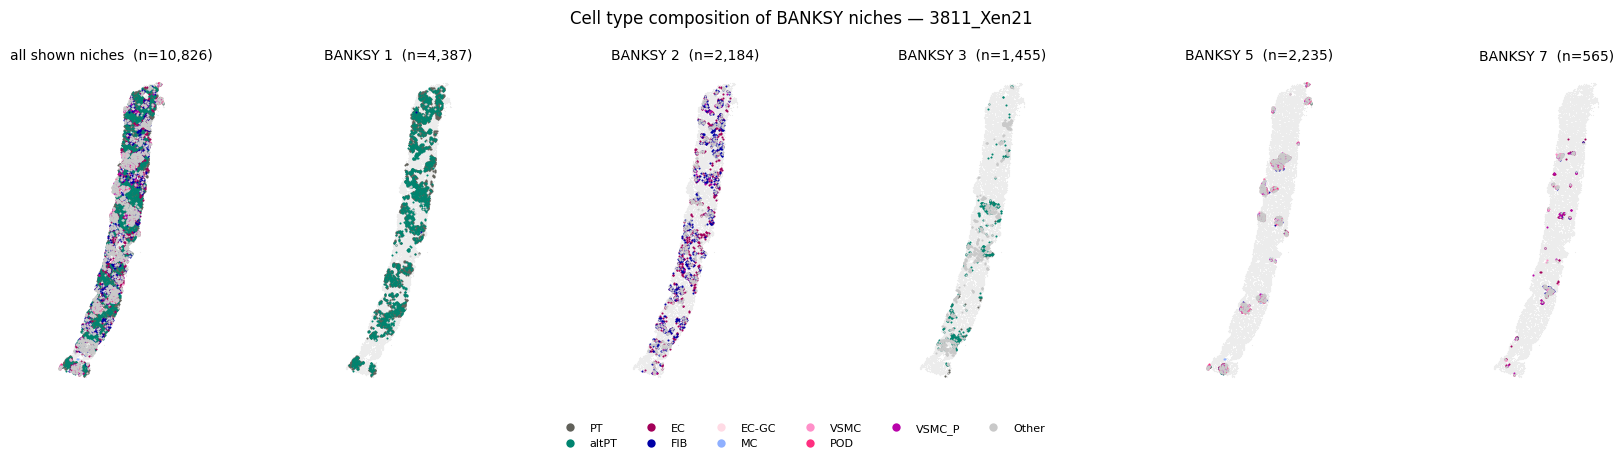

In [36]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


print(np.allclose(a.obsm["spatial"], a.obsm["X_spatial"]))
print(np.allclose(a.obsm["spatial"], a.obs[["x_centroid","y_centroid"]].values))

SAMPLE   = "3811_Xen21"
CT       = "v2.subclass.levelKIL"
CL       = "banksy_cluster_corrected"
clusters = ["1", "2", "3", "5", "7"]      # <-- adjust if X-labels are 1-indexed
min_frac = 0.02

sub = a[a.obs["sample"] == SAMPLE].copy()
xy  = np.asarray(sub.obsm["spatial"])
print(sub.n_obs, "cells;", sub.obs[CL].value_counts().to_dict())

ct_all = sub.obs[CT].astype(str).values
m_any  = sub.obs[CL].astype(str).isin(clusters).values
frac   = pd.Series(ct_all[m_any]).value_counts(normalize=True)
keep   = frac[frac >= min_frac].index.tolist()

base    = dict(zip(list(a.obs[CT].cat.categories), a.uns[f"{CT}_colors"]))
palette = {c: base[c] for c in keep}
palette["Other"] = "#c9c9c9"
ct_plot = np.where(np.isin(ct_all, keep), ct_all, "Other")

panels = ["ALL"] + clusters
fig, axes = plt.subplots(1, len(panels), figsize=(3.6*len(panels), 4.2))

for ax, p in zip(axes, panels):
    ax.scatter(xy[:,0], xy[:,1], s=0.7, c="#ececec", lw=0, rasterized=True)
    m = m_any if p == "ALL" else (sub.obs[CL].astype(str).values == p)
    for ct in [c for c in palette if c in set(ct_plot[m])]:
        mm = m & (ct_plot == ct)
        ax.scatter(xy[mm,0], xy[mm,1], s=2.2, c=[palette[ct]], lw=0, rasterized=True)
    ax.set_title(("all shown niches" if p=="ALL" else f"BANKSY {p}") + f"  (n={m.sum():,})",
                 fontsize=10)
    ax.set_aspect("equal"); ax.invert_yaxis(); ax.axis("off")

fig.legend(handles=[Line2D([0],[0], marker="o", ls="", ms=6, mfc=v, mec="none", label=k)
                    for k,v in palette.items()],
           loc="lower center", ncol=6, frameon=False, fontsize=8, bbox_to_anchor=(0.5,-0.05))
fig.suptitle(f"Cell type composition of BANKSY niches — {SAMPLE}", y=1.02)
fig.savefig(f"banksy_niche_celltypes_{SAMPLE}.pdf", bbox_inches="tight", dpi=400)

In [37]:
sub = a[a.obs["sample"] == "3811_Xen21"]
print(sub.obs["cell_id"].head().tolist())
print(sub.obs_names[:5].tolist())
print(sub.obs["cell_id"].duplicated().any())

['aaabbkdn-1', 'aaadbomk-1', 'aaaemjag-1', 'aaajkbcc-1', 'aaalhoek-1']
['aaabbkdn-1-3811_Xen21', 'aaadbomk-1-3811_Xen21', 'aaaemjag-1-3811_Xen21', 'aaajkbcc-1-3811_Xen21', 'aaalhoek-1-3811_Xen21']
False


In [38]:
import os
os.makedirs("explorer_groups", exist_ok=True)

CT, CL = "v2.subclass.levelKIL", "banksy_cluster_corrected"
clusters = ["1", "2", "3", "5", "7"]

# one CSV per cluster: groups = cell types within that niche
for cl in clusters:
    m = sub.obs[CL].astype(str) == cl
    out = sub.obs.loc[m, ["cell_id", CT]].copy()
    out.columns = ["cell_id", "group"]
    out["group"] = out["group"].astype(str).str.replace(",", "", regex=False)
    out.to_csv(f"explorer_groups/BANKSY_{cl}_celltypes.csv", index=False)
    print(cl, len(out), out["group"].nunique(), "groups")

# combined: all five niches at once, group = "X1 · PT" style
m = sub.obs[CL].astype(str).isin(clusters)
comb = sub.obs.loc[m, ["cell_id"]].copy()
comb["group"] = (sub.obs.loc[m, CL].astype(str).radd("X") + " · "
                 + sub.obs.loc[m, CT].astype(str).str.replace(",", "", regex=False))
comb.to_csv("explorer_groups/BANKSY_all_niches_celltypes.csv", index=False)

1 4387 11 groups
2 2184 37 groups
3 1455 24 groups
5 2235 35 groups
7 565 25 groups


## Change Colors and Cluster Numbers

In [39]:
# one number moves: N14 -> N12
WASHU_DISPLAY_NICHE_MAP_V2 = dict(WASHU_DISPLAY_NICHE_MAP, **{"12": "12"})

# keyed by CORRECTED cluster so they survive any future renumbering
WASHU_CLUSTER_COLORS = {
    "0":  "#E596BB",   # Fibroimmune
    "1":  "#4E3399",   # PT-rich A
    "2":  "#71F2BF",   # Fibrovascular A
    "3":  "#98E959",   # Altered-PT / thin limb
    "4":  "#ED6E69",   # TAL / MD
    "5":  "#F09F49",   # Glomerular
    "6":  "#3B6CD8",   # Fibrovascular B
    "7":  "#F2A6EB",   # Vascular / mural
    "8":  "#F5BD61",   # Mixed distal-interstitial
    "9":  "#E4D446",   # Collecting duct
    "10": "#C2BBFA",   # DCT / distal nephron
    "11": "#ABABAB",   # PT-rich B
    "12": "#54B8B8",   # PT-rich C
}

WASHU_DISPLAY_COLORS_V2 = {
    WASHU_DISPLAY_NICHE_MAP_V2[c]: hexv for c, hexv in WASHU_CLUSTER_COLORS.items()
}

assert set(WASHU_CLUSTER_COLORS) == set(WASHU_DISPLAY_NICHE_MAP_V2), "colour/map mismatch"
assert sorted(int(v) for v in WASHU_DISPLAY_NICHE_MAP_V2.values()) == list(range(13)), \
    "display niches are not contiguous"

changed = pd.DataFrame([
    {"CorrectedCluster": c,
     "NicheName": WASHU_NICHE_NAME_MAP[c],
     "Old": WASHU_DISPLAY_NICHE_MAP[c],
     "New": WASHU_DISPLAY_NICHE_MAP_V2[c],
     "Colour": WASHU_CLUSTER_COLORS[c]}
    for c in sorted(WASHU_DISPLAY_NICHE_MAP_V2, key=int)
])
changed["Changed"] = changed["Old"] != changed["New"]

changed.to_csv(FIGURE_DIR / "display_niche_crosswalk_v2.csv", index=False)
print(changed.to_string(index=False))
print(f"\n{changed['Changed'].sum()} label(s) changed")

CorrectedCluster                 NicheName Old New  Colour  Changed
               0               Fibroimmune   2   2 #E596BB    False
               1                 PT-rich_A   1   1 #4E3399    False
               2           Fibrovascular_A   0   0 #71F2BF    False
               3      Altered-PT_thin-limb   3   3 #98E959    False
               4                    TAL_MD   9   9 #ED6E69    False
               5                Glomerular   5   5 #F09F49    False
               6           Fibrovascular_B   7   7 #3B6CD8    False
               7            Vascular_mural   8   8 #F2A6EB    False
               8 Mixed_distal-interstitial   4   4 #F5BD61    False
               9           Collecting_duct  10  10 #E4D446    False
              10        DCT_distal-nephron   6   6 #C2BBFA    False
              11                 PT-rich_B  11  11 #ABABAB    False
              12                 PT-rich_C  14  12 #54B8B8     True

1 label(s) changed


In [40]:
from contextlib import contextmanager


@contextmanager
def fixed_palette(color_map):
    """
    Temporarily make make_cluster_palette return fixed colours, so the existing
    plotting functions can use them without being edited. Cohorts whose clusters
    are not all in color_map fall back to the original tab20 behaviour.
    """
    global make_cluster_palette
    original = make_cluster_palette

    def patched(cluster_values, cmap_name="tab20"):
        order = natural_sort(cluster_values)
        if all(c in color_map for c in order):
            return order, {c: color_map[c] for c in order}
        return original(cluster_values, cmap_name)

    make_cluster_palette = patched
    try:
        yield
    finally:
        make_cluster_palette = original

In [41]:
def prefix_cluster_labels(fig, washu_prefix="X", iu_prefix="IU X", split=0.5):
    """
    Prefix the y-axis cluster labels after the figure is drawn.

    Applied at label time rather than in the display map: natural_sort falls back
    to alphabetical for non-numeric values, so a map value of "X10" would order
    the axis X0, X1, X10, X11, X2 ... Keeping the map numeric preserves both the
    sort order and the colour-dict keys.

    Cohort is identified by axes position - left half is WASHU, right half IU.
    Only the leftmost panel of each cohort carries tick labels; the rest have
    labelleft=False and are skipped. Safe to call twice.
    """
    fig.canvas.draw()

    relabelled = 0
    for ax in fig.axes:
        labels = [t.get_text() for t in ax.get_yticklabels()]
        if not any(l.strip() for l in labels):
            continue

        prefix = washu_prefix if ax.get_position().x0 < split else iu_prefix
        ax.set_yticklabels([
            l if (not l.strip() or l.startswith(prefix)) else f"{prefix}{l}"
            for l in labels
        ])
        relabelled += 1

    if relabelled != 2:
        print(f"[warn] relabelled {relabelled} axes, expected 2 — check the layout")

    return fig

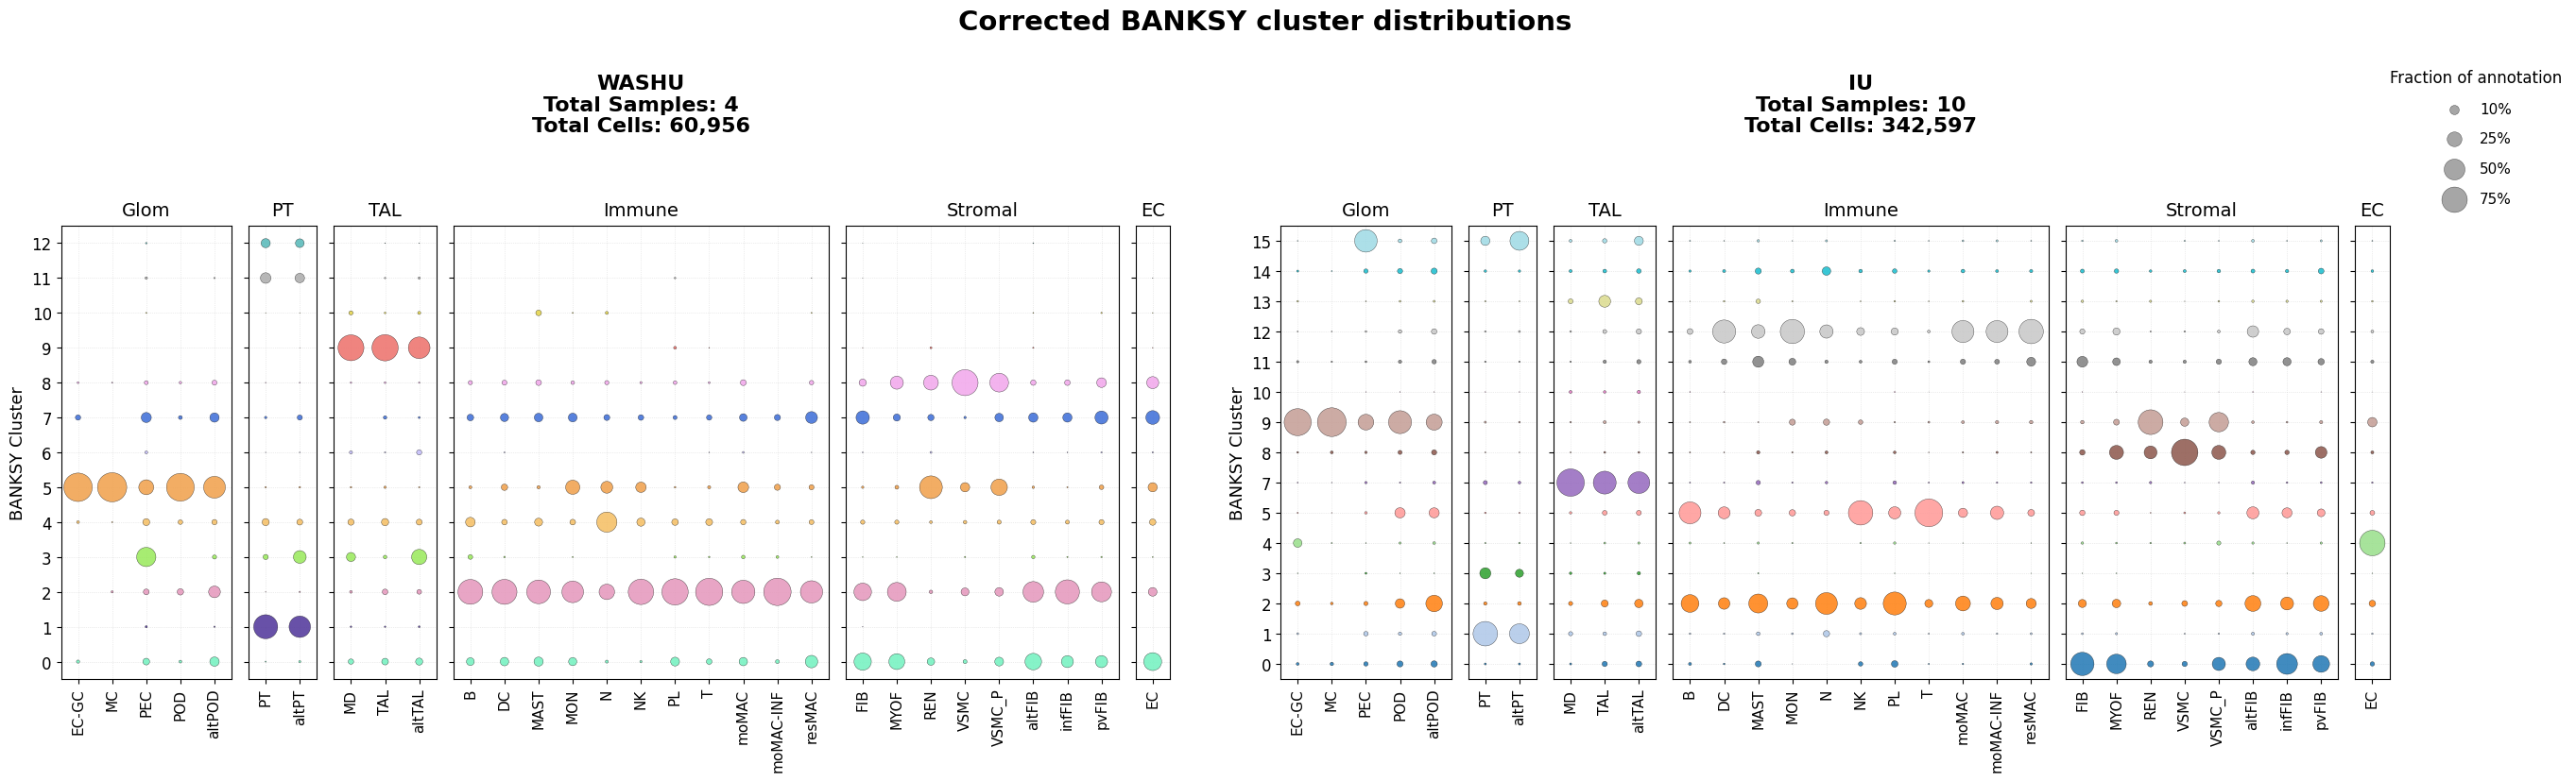

Saved PNG: results/corrected_banksy_tables/Corrected_BANKSY_compact_display_niche_numbers_v2.png
Saved PDF: results/corrected_banksy_tables/Corrected_BANKSY_compact_display_niche_numbers_v2.pdf


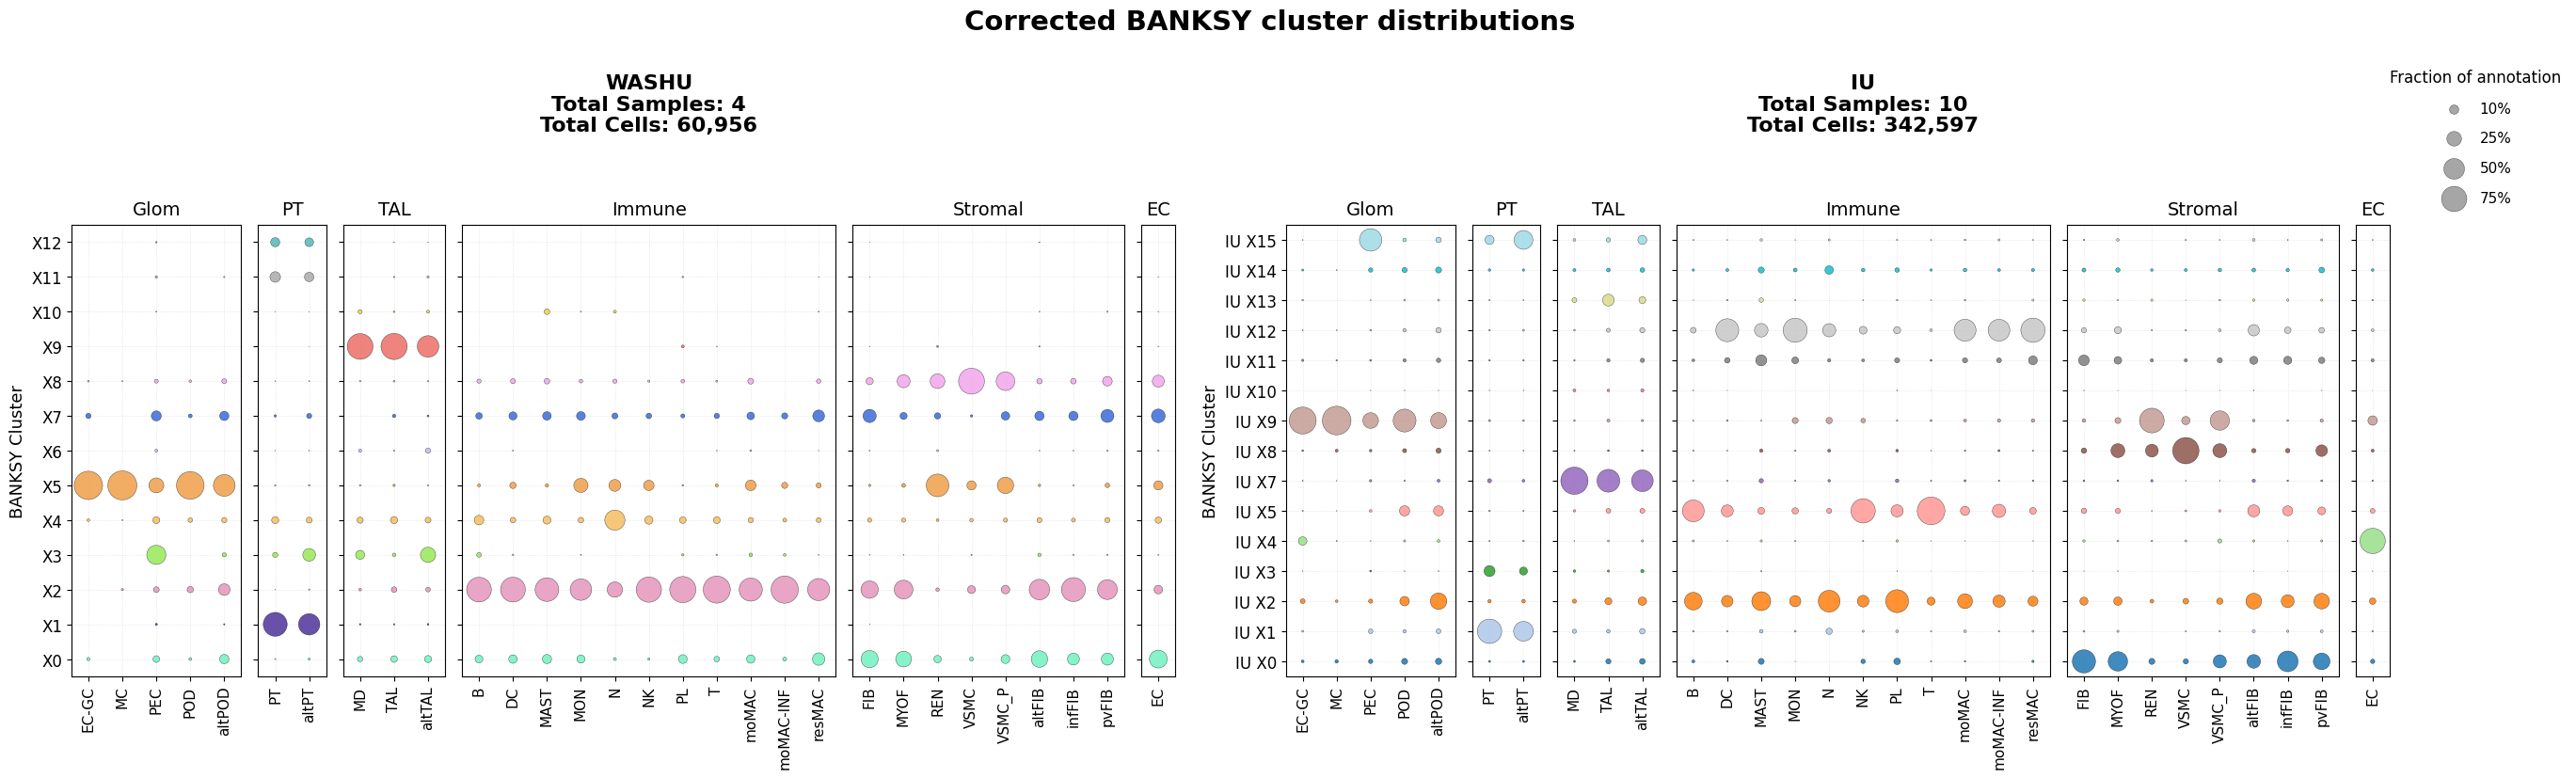

Re-saved with prefixed labels: results/corrected_banksy_tables/Corrected_BANKSY_compact_display_niche_numbers_v2.png


In [42]:
washu_cluster_annotation_display_v2 = apply_display_niche_numbers(
    washu_cluster_annotation, WASHU_DISPLAY_NICHE_MAP_V2, "WASHU",
)

V2_PREFIX = FIGURE_DIR / "Corrected_BANKSY_compact_display_niche_numbers_v2"

with fixed_palette(WASHU_DISPLAY_COLORS_V2):
    compact_v2_fig, bubble_tables_v2, panel_map_v2 = plot_two_cohort_bubble_figure(
        washu_cluster_annotation=washu_cluster_annotation_display_v2,
        iu_cluster_annotation=iu_cluster_annotation_display,   # IU unchanged
        washu_obs=washu_obs,
        iu_obs=iu_obs,
        panel_map=COMPACT_PANEL_MAP,
        figure_title="Corrected BANKSY cluster distributions",
        output_prefix=V2_PREFIX,
        metric_col="FractionOfAnnotation",
        size_scale=500,
        figsize=(28, 10),
        main_title_fontsize=21,
        cohort_title_fontsize=16,
        panel_title_fontsize=14,
        x_tick_fontsize=11,
        y_tick_fontsize=12,
        axis_label_fontsize=13,
        legend_fontsize=11,
        legend_title_fontsize=12,
        return_tables=True,
    )

# prefix the axis labels, then re-save over the files written inside the call
prefix_cluster_labels(compact_v2_fig, washu_prefix="X", iu_prefix="IU X")

compact_v2_fig.savefig(V2_PREFIX.with_suffix(".png"), dpi=300, bbox_inches="tight")
compact_v2_fig.savefig(V2_PREFIX.with_suffix(".pdf"), bbox_inches="tight")
display(compact_v2_fig)

print(f"Re-saved with prefixed labels: {V2_PREFIX.with_suffix('.png')}")

In [43]:
def export_cell_assignments(adata, display_map, name_map, color_map, out_path,
                            cluster_col=CLUSTER_COL, annotation_col=ANNOTATION_COL,
                            sample_col=SAMPLE_COL, cell_id_col=CELL_ID_COL):
    """One row per cell: id, sample, corrected cluster, display niche, name, annotation."""
    obs = adata.obs[[cell_id_col, sample_col, cluster_col, annotation_col]].copy()
    obs.columns = ["cell_id", "sample_id", "corrected_cluster", "annotation"]

    obs["corrected_cluster"] = obs["corrected_cluster"].astype(str)
    obs["display_niche"] = obs["corrected_cluster"].map(display_map)
    obs["niche_name"] = obs["corrected_cluster"].map(name_map)
    obs["niche_color"] = obs["corrected_cluster"].map(color_map)
    obs["niche_label"] = ("N" + obs["display_niche"] + "_" + obs["niche_name"]
                          + "_C" + obs["corrected_cluster"])
    obs["axis_label"] = "X" + obs["display_niche"]

    for col in ("display_niche", "niche_name", "niche_color"):
        assert obs[col].notna().all(), f"unmapped cluster in {col}"

    obs = obs[["cell_id", "sample_id", "corrected_cluster", "display_niche",
               "niche_name", "niche_label", "niche_color", "annotation"]]
    obs.to_csv(out_path, index=False)

    print(f"{len(obs):,} cells -> {out_path}")
    print(obs["niche_label"].value_counts().to_string())
    return obs


cell_assignments_v2 = export_cell_assignments(
    washu,
    WASHU_DISPLAY_NICHE_MAP_V2, WASHU_NICHE_NAME_MAP, WASHU_CLUSTER_COLORS,
    out_path=TABLE_DIR / "WASHU_cell_niche_assignments_v2.csv",
)

60,956 cells -> results/atlasv2_corrected_banksy_tables/WASHU_cell_niche_assignments_v2.csv
niche_label
N2_Fibroimmune_C0                  10388
N1_PT-rich_A_C1                     9604
N0_Fibrovascular_A_C2               7300
N3_Altered-PT_thin-limb_C3          5433
N9_TAL_MD_C4                        4843
N5_Glomerular_C5                    4767
N7_Fibrovascular_B_C6               4496
N8_Vascular_mural_C7                3340
N4_Mixed_distal-interstitial_C8     2632
N10_Collecting_duct_C9              2536
N6_DCT_distal-nephron_C10           2119
N11_PT-rich_B_C11                   2004
N12_PT-rich_C_C12                   1494


In [44]:
explorer_exports_v2 = export_explorer_selections(
    adata=washu,
    sample_id=EXPLORER_SAMPLE_ID,
    display_map=WASHU_DISPLAY_NICHE_MAP_V2,
    name_map=WASHU_NICHE_NAME_MAP,
    export_dir=EXPLORER_DIR / "v2",
)

 20,610 cells -> results/3811_Xen21_Xenium_Explorer/v2/3811_Xen21_corrected_BANKSY_clusters.csv
 20,610 cells -> results/3811_Xen21_Xenium_Explorer/v2/3811_Xen21_celltypes.csv
 20,610 cells -> results/3811_Xen21_Xenium_Explorer/v2/3811_Xen21_corrected_BANKSY_display_niches_named.csv


In [45]:
def export_niche_numbers(adata, sample_id, display_map, export_dir,
                         which="display", zero_pad=False,
                         cluster_col=CLUSTER_COL, sample_col=SAMPLE_COL,
                         cell_id_col=CELL_ID_COL):
    """
    Explorer selection CSV with a bare number in the group column.

    which="display"   -> the renumbered niche (matches the figure axis X0-X12)
    which="corrected" -> the underlying BANKSY cluster id
    """
    export_dir = Path(export_dir)
    export_dir.mkdir(parents=True, exist_ok=True)

    obs = adata.obs.loc[
        adata.obs[sample_col].astype(str).eq(sample_id),
        [cell_id_col, cluster_col],
    ].copy()

    if obs.empty:
        raise ValueError(f"No cells found for sample {sample_id!r}")

    corrected = obs[cluster_col].astype(str)

    if which == "display":
        group = corrected.map(display_map)
        assert group.notna().all(), "unmapped cluster in display_map"
    elif which == "corrected":
        group = corrected
    else:
        raise ValueError("which must be 'display' or 'corrected'")

   
    if zero_pad:
        group = group.str.zfill(2)

    frame = pd.DataFrame({"cell_id": obs[cell_id_col].astype(str), "group": group})

    assert frame["cell_id"].is_unique, "cell_id is not unique within the sample"

    path = export_dir / f"{sample_id}_niche_numbers_{which}.csv"
    frame.to_csv(path, index=False)

    print(f"{len(frame):>7,} cells -> {path}")
    print(frame["group"].value_counts().sort_index().to_string())
    return frame


niche_numbers = export_niche_numbers(
    adata=washu,
    sample_id=EXPLORER_SAMPLE_ID,
    display_map=WASHU_DISPLAY_NICHE_MAP_V2,
    export_dir=EXPLORER_DIR / "v2",
    which="display",
)

 20,610 cells -> results/3811_Xen21_Xenium_Explorer/v2/3811_Xen21_niche_numbers_display.csv
group
0     2184
1     4387
10     936
11     461
12     714
2     3334
3     1455
4      559
5     2235
6      841
7     1869
8      565
9     1070


In [47]:
def export_per_sample_csvs(adata, display_map, name_map, out_dir,
                           samples=None, write_explorer=True,
                           cluster_col=CLUSTER_COL, annotation_col=ANNOTATION_COL,
                           sample_col=SAMPLE_COL, cell_id_col=CELL_ID_COL):
    """
    One CSV per sample: cell_id, group (cell type), and BANKSY niche columns.

    Also writes two-column Explorer-importable files if write_explorer=True, since
    Explorer selections accept only cell_id,group.
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    obs = adata.obs[[cell_id_col, sample_col, cluster_col, annotation_col]].copy()
    obs.columns = ["cell_id", "sample_id", "corrected_cluster", "group"]
    obs["cell_id"] = obs["cell_id"].astype(str)
    obs["sample_id"] = obs["sample_id"].astype(str)
    obs["corrected_cluster"] = obs["corrected_cluster"].astype(str)
    obs["group"] = obs["group"].astype(str)

    obs["display_niche"] = obs["corrected_cluster"].map(display_map)
    obs["niche_name"] = obs["corrected_cluster"].map(name_map)
    obs["niche_label"] = "X" + obs["display_niche"]

    for col in ("display_niche", "niche_name"):
        assert obs[col].notna().all(), f"unmapped cluster in {col}"

    samples = samples or sorted(obs["sample_id"].unique())
    print(f"{len(samples)} sample(s): {samples}\n")

    written = {}
    for sample_id in samples:
        sub = obs.loc[obs["sample_id"] == sample_id].copy()

        if sub.empty:
            raise ValueError(f"No cells for sample {sample_id!r}")
        if not sub["cell_id"].is_unique:
            raise ValueError(f"{sample_id}: cell_id is not unique")

        full = sub[["cell_id", "group", "display_niche", "niche_label",
                    "niche_name", "corrected_cluster"]]
        path = out_dir / f"{sample_id}_celltype_and_niche.csv"
        full.to_csv(path, index=False)
        written[sample_id] = full

        print(f"{sample_id:<20} {len(full):>8,} cells  "
              f"{full['group'].nunique():>3} cell types  "
              f"{full['display_niche'].nunique():>3} niches -> {path.name}")

        if write_explorer:
            sub[["cell_id", "group"]].to_csv(
                out_dir / f"{sample_id}_explorer_celltypes.csv", index=False)
            # niche_label ("X2") rather than display_niche ("2"), so the Explorer
            # legend reads identically to the bubble plot axis.
            (sub[["cell_id", "niche_label"]]
             .rename(columns={"niche_label": "group"})
             .to_csv(out_dir / f"{sample_id}_explorer_niches.csv", index=False))


    return written


per_sample_csvs = export_per_sample_csvs(
    adata=washu,
    display_map=WASHU_DISPLAY_NICHE_MAP_V2,
    name_map=WASHU_NICHE_NAME_MAP,
    out_dir=EXPLORER_DIR / "v2" / "per_sample",
)

4 sample(s): ['3729_Xen21', '3809_Xen22A', '3809_Xen22B', '3811_Xen21']

3729_Xen21             12,330 cells   45 cell types   13 niches -> 3729_Xen21_celltype_and_niche.csv
3809_Xen22A            14,073 cells   45 cell types   13 niches -> 3809_Xen22A_celltype_and_niche.csv
3809_Xen22B            13,943 cells   45 cell types   13 niches -> 3809_Xen22B_celltype_and_niche.csv
3811_Xen21             20,610 cells   45 cell types   13 niches -> 3811_Xen21_celltype_and_niche.csv


In [48]:
source_data_v2 = pd.concat([
    build_source_data(bubble_tables_v2["WASHU"], washu_cluster_annotation_display_v2,
                      washu_obs, "WASHU", "FractionOfAnnotation"),
    build_source_data(bubble_tables_v2["IU"], iu_cluster_annotation_display,
                      iu_obs, "IU", "FractionOfAnnotation"),
], ignore_index=True)


source_data_v2["AxisLabel"] = np.where(
    source_data_v2["Cohort"] == "WASHU",
    "X" + source_data_v2["DisplayNiche"],
    "IU X" + source_data_v2["DisplayNiche"],
)

cols = list(source_data_v2.columns)
cols.insert(cols.index("DisplayNiche") + 1, cols.pop(cols.index("AxisLabel")))
source_data_v2 = source_data_v2[cols]

notes_v2 = pd.DataFrame({"Note": [
    "Bubble size encodes FractionOfAnnotation = nCellsAnnotationInCluster / "
    "nCellsAnnotationTotal, computed within cohort.",
    "AxisLabel matches the y-axis of the figure exactly (WASHU 'X0'-'X12', IU 'IU X0'-).",
    "DisplayNiche is the figure number. CorrectedCluster is the BANKSY cluster id in "
    "the deposited objects; the two differ for 8 of 13 WASHU clusters. See the "
    "'Cluster renumbering' sheet.",
    "WASHU display niches were renumbered contiguously 0-12; the cluster previously "
    "labelled N14 is now N12. Same cells, same cluster, new label.",
    "IU display niches are unchanged from the original analysis.",
    "Bubble colour encodes cluster identity only and carries no quantitative value; "
    "WASHU colours match the Xenium Explorer niche colours (see crosswalk).",
    "Cluster x cell type combinations with zero cells are omitted; a missing row is a "
    "true absence, not a suppressed zero.",
]})

path_v2 = SOURCE_DATA_DIR / "SourceData_BANKSY_bubble_plot_v2.xlsx"

with pd.ExcelWriter(path_v2) as writer:
    source_data_v2.to_excel(writer, sheet_name="Bubble plot", index=False)
    changed.to_excel(writer, sheet_name="Cluster renumbering", index=False)
    notes_v2.to_excel(writer, sheet_name="Notes", index=False)

source_data_v2.to_csv(SOURCE_DATA_DIR / "SourceData_BANKSY_bubble_plot_v2.csv", index=False)

print(f"Wrote {path_v2}")
print(f"{len(source_data_v2):,} bubbles")
print(source_data_v2.groupby("Cohort")["DisplayNiche"].nunique().to_string())

Wrote results/source_data/SourceData_BANKSY_bubble_plot_v2.xlsx
674 bubbles
Cohort
IU       15
WASHU    13
